# ⚽ Deep Learning & AI in Football: Tactical Clustering and Player Archetypes

### 🧩 Module Overview
This module demonstrates how **unsupervised learning** methods such as **KMeans**, **Agglomerative Clustering**, and **t-SNE** can be applied to **football event and tracking data** to reveal hidden tactical patterns — from team formations and playing styles to player archetypes.

By the end, we will have a complete data pipeline that moves from **raw spatiotemporal data** to **interpretable tactical insights**.

---

## 🎯 Learning Objectives
After completing this module, you will be able to:

1. **Preprocess tracking data** and normalize directions to ensure spatial consistency.  
2. **Extract and visualize team formations** using player positional averages.  
3. **Cluster team possessions** to identify distinct *playing styles* (e.g., build-up, counterattack, direct play).  
4. **Generate player embeddings** using t-SNE to represent stylistic similarity and role archetypes.  
5. **Interpret clustering results** in tactical terms — formations, play styles, and player types.  

---

## 🧠 Key Concepts Covered
| Concept | Description |
|----------|--------------|
| **Unsupervised Learning** | Discovering patterns in football data without predefined labels. |
| **Dimensionality Reduction (PCA, t-SNE)** | Mapping high-dimensional tactical features into interpretable 2D/3D spaces. |
| **Clustering (KMeans, Agglomerative)** | Grouping possessions, formations, or players into stylistically similar categories. |
| **Tactical Representation** | Translating cluster centroids and feature loadings into meaningful football interpretations (e.g., 4–3–3, direct transitions). |

---

## 🧰 Data Inputs
We will use both **event data** and **tracking data**, already merged into `df_freeze` format, which includes:
- Ball and player positions (`x`, `y`)
- Event types (e.g., pass, reception, interception)
- Team and player metadata
- Possession identifiers (`possession_id`)
- Normalized spatial coordinates (`x_rescaled`, `y_rescaled`)

---

## 🪄 Module Structure

| Part | Focus | Methods Used |
|------|--------|---------------|
| **Part 0** | Data preprocessing | Direction normalization, ball-in-play filtering |
| **Part 1** | Formation analysis | Mean position extraction, KMeans & Agglomerative clustering |
| **Part 2** | Playing style clustering | Possession-level features, PCA, radar plots |
| **Part 3** | Player similarity & archetypes | Player-level features, t-SNE, cosine similarity |
| **Part 4** | Interpretation | Tactical labeling and visualization |

---

### 💡 Motivation
Football is rich in **continuous spatial data** — formations, movements, and transitions evolve dynamically.  
By leveraging **unsupervised AI methods**, analysts can quantify and visualize these hidden patterns, revealing:
- How teams organize spatially,
- How they build attacks,
- And which players share similar functional roles.

---

**Let’s begin our tactical journey: from pixels and frames → to formations, playing styles, and archetypes. ⚽**


# 🧩 Step 0 — Preprocessing and Match-Level Data Preparation

Before performing any formation or playing style analysis, we first need to **standardize and preprocess** the tracking and event data for each match in the league.  
This ensures that all positional data are consistent, synchronized, and analytically meaningful.

---

### ⚙️ Overview

For each match, the preprocessing pipeline performs the following key steps:

1. **Load match data**
   - Loads raw **tracking**, **event**, and **metadata** files for a given `match_id`.
   - These contain player coordinates, event timestamps, and team/player identifiers.

2. **Merge metadata**
   - Enriches the tracking data with player and team information  
     (`team_id`, `player_role`, `position_group`, etc.).

3. **Normalize attack direction**
   - Ensures all teams are attacking **left-to-right** (`x=0 → 105`),  
     flipping coordinates where necessary to make formations comparable across matches.

4. **Compute ball kinematics**
   - Calculates ball velocity and movement patterns to later identify **ball-in-play** moments.

5. **Filter ball-in-play and 11v11 frames**
   - Removes stoppages, dead-ball periods, and phases where fewer than 11 players per team are detected.

6. **Build possession mask**
   - Assigns which team is **in possession** at each frame, based on event boundaries (`frame_start`, `frame_end`).

7. **Save processed tracking data**
   - Saves the cleaned, enriched dataset for each match in a separate `.parquet` file  
     under the folder `processed_tracking/`.

---

### 💾 Output

Each processed file (`match_id.parquet`) contains frame-level data with:

| Column | Description |
|---------|-------------|
| `match_id` | Match identifier |
| `frame` | Frame number |
| `player_id` | Player identifier |
| `x_norm`, `y_norm` | Normalized player coordinates (left-to-right attack) |
| `team_id`, `team_name` | Team information |
| `ball_in_play` | Boolean mask for active play |
| `in_possession_team` | Team currently in possession |
| `position_group` | Role grouping (e.g., Midfield, Defender, Forward) |

---

### 🧠 Why This Step Matters

This preprocessing step ensures that all subsequent analyses —  
like **formation clustering**, **possession-level playing style analysis**, and **player similarity modeling** —  
start from a consistent, interpretable foundation.  

By aligning all matches to a common coordinate frame and filtering noise,  
we can meaningfully compare tactical structures across the entire league.


In [6]:
#/Users/pegra441/Desktop/twelve-deep-learning/teams.parquet

In [7]:
from pathlib import Path

Path.cwd().parents[0]

PosixPath('/home/macaco3001/Projectos/Twelve/twelve-deep-learning')

In [8]:
# Cell 0: imports & constants

import os, json
from pathlib import Path
import pandas as pd
import numpy as np

# --- Paths (yours) ---
ROOT = Path.cwd().parents[0]
DYNAMIC_DIR = ROOT / "PremierLeague_data/2024/dynamic"
META_DIR = ROOT / "PremierLeague_data/2024/meta"
TRACKING_DIR = ROOT / "PremierLeague_data/2024/tracking"
PROCESSED_DIR = ROOT / "PremierLeague_data/2024/processed"
PROCESSED_DIR.mkdir(exist_ok=True)
ROLE_AVG_DIR = ROOT / "PremierLeague_data/2024/role_avg"
ROLE_AVG_DIR.mkdir(exist_ok=True)

# Pitch constants (SkillCorner → 105x68, origin at left-bottom after rescale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105.0, 68.0

In [9]:
# Cell 2: check tracking (.json) + event (.parquet) availability

def check_data_availability(df_matches, dynamic_dir=DYNAMIC_DIR, tracking_dir=TRACKING_DIR):
    # Collect available IDs
    dynamic_ids = {int(f.stem) for f in dynamic_dir.glob("*.parquet")}
    tracking_ids = {int(f.stem) for f in tracking_dir.glob("*.json")}

    # Add flags to df
    df_matches["has_dynamic"] = df_matches["id"].isin(dynamic_ids)
    df_matches["has_tracking"] = df_matches["id"].isin(tracking_ids)
    df_matches["has_both"] = df_matches["has_dynamic"] & df_matches["has_tracking"]

    # Summary printout
    total = len(df_matches)
    both = df_matches["has_both"].sum()
    print(f"✅ {both}/{total} matches have both event + tracking data ({both/total:.1%})")

    return df_matches

#df_matches_checked = check_data_availability(df_matches)
#df_matches_checked.head()



In [10]:
# Cell 3: count matches per source

def summarize_data_counts(dynamic_dir=DYNAMIC_DIR, tracking_dir=TRACKING_DIR, meta_dir=META_DIR):
    # Count files by extension
    n_dynamic = len(list(dynamic_dir.glob("*.parquet")))
    n_tracking = len(list(tracking_dir.glob("*.json")))
    n_meta = len(list(meta_dir.glob("*.json")))

    print("📦 Data Availability Summary")
    print("----------------------------")
    print(f"🎯 Event (dynamic) matches : {n_dynamic}")
    print(f"🎥 Tracking (json) matches : {n_tracking}")
    print(f"🧾 Meta (json) files       : {n_meta}")

    # Optionally, cross-check
    if abs(n_dynamic - n_tracking) > 0:
        print(f"⚠️ Difference detected between event and tracking counts ({n_dynamic - n_tracking:+d})")

summarize_data_counts()


📦 Data Availability Summary
----------------------------
🎯 Event (dynamic) matches : 378
🎥 Tracking (json) matches : 380
🧾 Meta (json) files       : 380
⚠️ Difference detected between event and tracking counts (-2)


In [11]:
# Cell 4: find missing matches between event and tracking

def find_missing_files(dynamic_dir=DYNAMIC_DIR, tracking_dir=TRACKING_DIR):
    # Collect match IDs
    dynamic_ids = {int(f.stem) for f in dynamic_dir.glob("*.parquet")}
    tracking_ids = {int(f.stem) for f in tracking_dir.glob("*.json")}

    # Compare sets
    missing_in_tracking = sorted(dynamic_ids - tracking_ids)
    missing_in_dynamic = sorted(tracking_ids - dynamic_ids)

    print("🔍 Missing Files Report")
    print("------------------------")
    if missing_in_tracking:
        print(f"⚠️ Missing TRACKING files for {len(missing_in_tracking)} matches:")
        print(missing_in_tracking)
    else:
        print("✅ No tracking files missing.")

    if missing_in_dynamic:
        print(f"⚠️ Missing EVENT (dynamic) files for {len(missing_in_dynamic)} matches:")
        print(missing_in_dynamic)
    else:
        print("✅ No event files missing.")

find_missing_files()


🔍 Missing Files Report
------------------------
✅ No tracking files missing.
⚠️ Missing EVENT (dynamic) files for 2 matches:
[1651704, 2004169]


In [12]:
# Cell 1: build/refresh matches index (id, home_team, away_team)

matches_file = ROOT / "matches.parquet"
if not matches_file.exists():
    rows = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        meta_path = META_DIR / f"{match_id}.json"
        home_team = away_team = None
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        rows.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(rows)
    df_matches.to_parquet(matches_file, index=False)
else:
    df_matches = pd.read_parquet(matches_file)

print(f"✅ Matches loaded: {len(df_matches)}")
df_matches.head()


✅ Matches loaded: 378


,id,home_team,away_team
0,1800191,Manchester United,Brentford FC
1,1902568,Tottenham Hotspur,Chelsea
2,1897172,Bournemouth,Tottenham Hotspur
3,2004173,Everton,Manchester United
4,2016342,Fulham,Everton


In [13]:
# Cell 2: load helpers (meta, events, tracking) and rescale

def rescale_to_pitch_xy(x, y):
    """Map SkillCorner [-52..52, -34..34] to 105x68 meters."""
    xr = (x - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH
    yr = (y - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH
    return xr, yr

def load_meta_mapping(match_id: int) -> pd.DataFrame:
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        return pd.DataFrame()
    with open(fpath, "r") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]
    rows = []
    for p in meta.get("players", []):
        if "id" not in p:
            continue
        team = home_team if p["team_id"] == home_team["id"] else away_team
        rows.append({
            "match_id": meta["id"],
            "player_id": p["id"],                      # aligns to tracking 'player_id'
            "team_id": p["team_id"],
            "team_name": team["name"],
            "team_short": team["short_name"],
            "player_short_name": p.get("short_name"),
            "player_role": p.get("player_role", {}).get("name"),
            "position_group": p.get("player_role", {}).get("position_group"),
            "home_team_id": home_team["id"],
            "away_team_id": away_team["id"],
        })
    return pd.DataFrame(rows)

def load_events_basic(match_id: int) -> pd.DataFrame:
    fpath = DYNAMIC_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        return pd.DataFrame()
    df = pd.read_parquet(fpath)
    keep = [
        "event_id","match_id","event_type","team_id","player_id",
        "time_start","time_end","frame_start","frame_end",
        "attacking_side","start_type","end_type","x_start","y_start","x_end","y_end",
        "period"
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def load_tracking_full(match_id: int, sort_rows: bool = False, require_ball_detected: bool = True) -> pd.DataFrame:
    fpath = TRACKING_DIR / f"{match_id}.json"
    if not fpath.exists():
        raise FileNotFoundError(f"No tracking for match {match_id}")
    with open(fpath, "r") as f:
        raw = json.load(f)

    rows = []
    for d in raw:
        frame = int(d.get("frame"))
        ts = d.get("timestamp")
        period = d.get("period")

        # Players (be robust if key is missing or None)
        players = d.get("player_data") or []
        for p in players:
            pid = p.get("player_id")
            rows.append({
                "match_id": match_id,
                "time": ts,
                "frame": frame,
                "period": period,
                "player_id": pid,
                "is_detected": bool(p.get("is_detected", False)),
                "is_ball": False,
                "x": p.get("x"),
                "y": p.get("y"),
            })

        # Ball (only append if we actually have a meaningful record)
        ball = d.get("ball_data")
        if ball is not None:
            if (not require_ball_detected) or (ball.get("is_detected") is not None):
                rows.append({
                    "match_id": match_id,
                    "time": ts,
                    "frame": frame,
                    "period": period,
                    "player_id": -1,
                    "is_detected": bool(ball.get("is_detected", False)),
                    "is_ball": True,
                    "x": ball.get("x"),
                    "y": ball.get("y"),
                })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Enforce dtypes
    df["is_ball"] = df["is_ball"].astype(bool)
    df["is_detected"] = df["is_detected"].astype(bool)
    df["frame"] = df["frame"].astype(int)

    # Rescale (105x68)
    def _rescale_row(r):
        xr = (r["x"] - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH if pd.notna(r["x"]) else np.nan
        yr = (r["y"] - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH  if pd.notna(r["y"]) else np.nan
        return pd.Series((xr, yr))
    #df[["x_rescaled","y_rescaled"]] = df.apply(_rescale_row, axis=1)
    den_x = (X_MAX - X_MIN); den_y = (Y_MAX - Y_MIN)
    valid_xy = df[["x","y"]].notna().all(axis=1)
    df["x_rescaled"] = np.where(valid_xy, (df["x"] - X_MIN) / den_x * PITCH_LENGTH, np.nan)
    df["y_rescaled"] = np.where(valid_xy, (df["y"] - Y_MIN) / den_y * PITCH_WIDTH, np.nan)


    # Optional sort (avoid putting the ball first if you're just inspecting head())
    if sort_rows:
        df = df.sort_values(["frame","is_ball","player_id"]).reset_index(drop=True)
        # Note: sorting by is_ball puts players (False) before ball (True)
    else:
        df = df.sort_values(["frame"]).reset_index(drop=True)

    # --- Quick debug summary (remove if noisy) ---
    n_ball = int(df["is_ball"].sum())
    n_player = int((~df["is_ball"]).sum())
    print(f"[match {match_id}] rows: {len(df)}, players: {n_player}, ball: {n_ball}")

    return df


In [14]:
# Cell 2b: example load
example_match = int(df_matches["id"].iloc[1])
meta_ex = load_meta_mapping(example_match)
ev_ex   = load_events_basic(example_match)
tr_ex   = load_tracking_full(example_match)
print(example_match, meta_ex.shape, ev_ex.shape, tr_ex.shape)
tr_ex.head(20)

[match 1902568] rows: 880164, players: 841896, ball: 38268
1902568 (40, 10) (4563, 17) (880164, 11)


,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,y_rescaled
0,1902568,00:00:00.00,10,1,34082,False,False,-39.96,-0.43,12.155769,33.57
1,1902568,00:00:00.00,10,1,-1,True,True,-0.07,-0.14,52.429327,33.86
2,1902568,00:00:00.00,10,1,2816,True,False,-0.81,0.67,51.682212,34.67
3,1902568,00:00:00.00,10,1,4314,True,False,0.59,-21.37,53.095673,12.63
4,1902568,00:00:00.00,10,1,26671,True,False,0.35,27.30,52.853365,61.30
5,1902568,00:00:00.00,10,1,24053,True,False,0.72,12.21,53.226923,46.21
6,1902568,00:00:00.00,10,1,32567,True,False,0.67,-11.41,53.176442,22.59
7,1902568,00:00:00.00,10,1,32071,True,False,10.31,-19.90,62.909135,14.10
8,1902568,00:00:00.00,10,1,13985,True,False,8.06,11.89,60.637500,45.89
9,1902568,00:00:00.00,10,1,38008,True,False,22.61,-9.72,75.327404,24.28


In [15]:
import pandas as pd
import numpy as np

def to_seconds(series: pd.Series) -> pd.Series:
    """
    Convert time to seconds.
    Handles strings like 'HH:MM:SS.ff' (e.g., '00:00:00.10'),
    numeric seconds, and large integers/floats in ms.
    Returns a float Series.
    """
    # if already numeric-ish, start there
    s_num = pd.to_numeric(series, errors="coerce")

    # try timedelta parsing for strings like HH:MM:SS.ff
    s_td = pd.to_timedelta(series.astype(str).str.strip().str.replace(",", ".", regex=False),
                           errors="coerce")
    s_sec_td = s_td.dt.total_seconds()

    # prefer timedelta parse when available, else numeric
    s = s_sec_td.fillna(s_num)

    # if values look like milliseconds (very large), convert to seconds
    if s.notna().any():
        median_val = s.dropna().median()
        # heuristic: median > 1e6 suggests ms ticks (e.g., 1,650,000,000)
        if median_val is not None and median_val > 1e6:
            s = s / 1000.0

    return s.astype(float)

In [16]:
def estimate_fps_from_time_df(df: pd.DataFrame, group_cols=("match_id",)) -> float:
    """
    Estimate frames-per-second from median time delta.
    Works even if you pass only ball rows or all rows.
    """
    t = to_seconds(df["time"])
    # compute dt within each group (match)
    if not isinstance(group_cols, (list, tuple)):
        group_cols = (group_cols,)
    dt = t.groupby([df[c] for c in group_cols]).diff().astype(float)
    dt = dt[(dt > 0) & dt.notna()]
    if dt.empty:
        return 25.0
    fps = 1.0 / float(dt.median())
    return float(np.clip(fps, 5, 120))


In [17]:
# Prefer ball rows (usually present in every frame)
ball_rows = tr_ex[tr_ex["is_ball"]]
fps = estimate_fps_from_time_df(ball_rows, group_cols=("match_id",))
print("Estimated FPS:", fps)


Estimated FPS: 10.000000000009095


## 📘 Ball Speed Calculation – Step by Step

1. Why do we clean the data?

Tracking data is noisy. If we use it raw:

Missing frames → fake zero speeds

Camera jitter → fake speed spikes

Wrong units → meaningless numbers

So we:

Parse time → convert "00:00:00.10" into seconds

Estimate FPS → how many frames per second (≈10 Hz)

Interpolate short gaps → connect missing dots (≤ 0.3–0.5s)

Smooth → remove jitter (≈ 0.6–1.0s window)

Compute speed = sqrt(vx² + vy²) in m/s

Clip unrealistic spikes (e.g. > 40 m/s)

2. Intuition (explain like I’m 10)

Interpolation: connect missing pages in a flipbook so the ball doesn’t disappear

Smoothing: trace over a wiggly line with a thicker pencil

Velocity: how much the dot moved since the last page

Speed: how fast the dot is moving (m/s)

Clip: ignore superhero glitches

3. Recommended defaults

interp_gap_s = 0.4 seconds

smooth_window_s = 0.7 seconds

clip_speed_mps = 40 m/s (~144 km/h)

Ball-in-play threshold = speed ≥ 1.0 m/s, with ±1s dilation

In [18]:
def compute_ball_kinematics(tr_df: pd.DataFrame,
                            interp_gap_s: float = 0.40,
                            smooth_window_s: float = 0.70,
                            clip_speed_mps: float = 40.0) -> pd.DataFrame:
    """
    Returns one row per ball frame with columns:
      match_id, frame, time_s, x_s, y_s, vx_mps, vy_mps, speed_mps, fps_used
    """
    ball = tr_df[tr_df["is_ball"]].copy()
    # parse time
    ball["time_s"] = to_seconds(ball["time"])
    # numeric positions
    ball["x_rescaled"] = pd.to_numeric(ball["x_rescaled"], errors="coerce")
    ball["y_rescaled"] = pd.to_numeric(ball["y_rescaled"], errors="coerce")
    ball["frame"] = pd.to_numeric(ball["frame"], errors="coerce")

    # sort per match/frame
    ball = ball.sort_values(["match_id", "frame"]).reset_index(drop=True)

    # fps & dt
    fps = estimate_fps_from_time_df(ball, group_cols=("match_id",))
    dt = 1.0 / fps

    # convert seconds -> frames for parameters
    max_gap_frames = max(1, int(round(interp_gap_s * fps)))
    window_frames  = max(3, int(round(smooth_window_s * fps)))
    if window_frames % 2 == 0:  # make odd for centered window
        window_frames += 1

    # interpolate short gaps only
    x = ball["x_rescaled"]
    y = ball["y_rescaled"]
    x_i = x.interpolate(limit=max_gap_frames, limit_direction="both")
    y_i = y.interpolate(limit=max_gap_frames, limit_direction="both")

    # smooth with centered rolling median
    x_s = x_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()
    y_s = y_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()


    #x_s, y_s are the smoothed/interpolated positions used to compute speed.

    # central differences for velocity
    vx = (x_s.shift(-1) - x_s.shift(1)) / (2*dt)
    vy = (y_s.shift(-1) - y_s.shift(1)) / (2*dt)

    speed = np.sqrt(vx**2 + vy**2).clip(lower=0, upper=clip_speed_mps)

    kin = pd.DataFrame({
        "match_id": ball["match_id"].values,
        "frame":    ball["frame"].astype("Int64").values,
        "time_s":   ball["time_s"].values,
        "x_s":      x_s.values,
        "y_s":      y_s.values,
        "vx_mps":   vx.values,
        "vy_mps":   vy.values,
        "speed_mps": speed.values,
        "fps_used": fps
    })
    return kin


In [19]:
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.40, smooth_window_s=0.70)
kin.head(12)


,match_id,frame,time_s,x_s,y_s,vx_mps,vy_mps,speed_mps,fps_used
0,1902568,10,0.0,52.535337,33.56,NaN,NaN,NaN,10.0
1,1902568,11,0.1,52.500000,33.60,-0.302885,0.50,0.584585,10.0
2,1902568,12,0.2,52.474760,33.66,-0.252404,0.60,0.650928,10.0
3,1902568,13,0.3,52.449519,33.72,0.075721,0.30,0.309409,10.0
4,1902568,14,0.4,52.489904,33.72,0.201923,0.35,0.404070,10.0
5,1902568,15,0.5,52.489904,33.79,0.000000,0.35,0.350000,10.0
6,1902568,16,0.6,52.489904,33.79,0.000000,0.00,0.000000,10.0
7,1902568,17,0.7,52.489904,33.79,0.252404,0.00,0.252404,10.0
8,1902568,18,0.8,52.540385,33.79,0.353365,-0.05,0.356885,10.0
9,1902568,19,0.9,52.560577,33.78,0.201923,-0.10,0.225328,10.0


In [20]:
print("Speed stats (m/s):")
print(kin["speed_mps"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

Speed stats (m/s):
count    38266.00
mean         5.79
std          5.55
min          0.00
50%          4.17
90%         13.69
99%         22.83
max         40.00
Name: speed_mps, dtype: float64


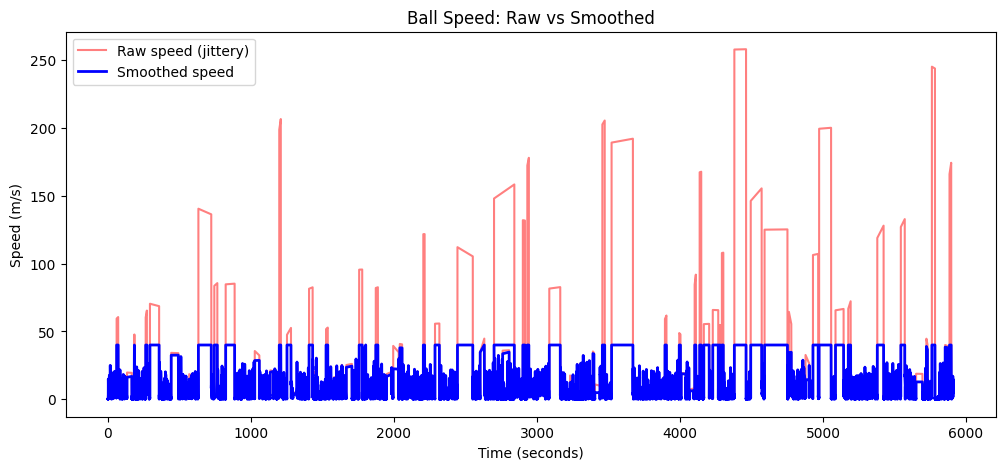

In [21]:
import matplotlib.pyplot as plt

# Take a slice of ball data
ball = tr_ex[tr_ex["is_ball"]].copy()
ball["time_s"] = to_seconds(ball["time"])

# Raw speed (no interp, no smoothing)
fps = estimate_fps_from_time_df(ball)
dt = 1.0 / fps
x_raw = ball["x_rescaled"].astype(float)
y_raw = ball["y_rescaled"].astype(float)
vx_raw = (x_raw.shift(-1) - x_raw.shift(1)) / (2*dt)
vy_raw = (y_raw.shift(-1) - y_raw.shift(1)) / (2*dt)
speed_raw = np.sqrt(vx_raw**2 + vy_raw**2)

# Cleaned speed
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.4, smooth_window_s=0.7)
speed_clean = kin.set_index("frame")["speed_mps"]

# Align by frame
df_plot = pd.DataFrame({
    "time_s": ball["time_s"].values,
    "speed_raw": speed_raw.values,
    "speed_clean": speed_clean.reindex(ball["frame"].values).values
})

# Plot
plt.figure(figsize=(12,5))
plt.plot(df_plot["time_s"], df_plot["speed_raw"], alpha=0.5, label="Raw speed (jittery)", color="red")
plt.plot(df_plot["time_s"], df_plot["speed_clean"], label="Smoothed speed", color="blue", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Ball Speed: Raw vs Smoothed")
plt.legend()
plt.show()


## 🟢 What is the Ball-in-Play mask?

It’s a flag for each frame: True if the game is live, False if the ball is out, in set-piece prep, halftime, etc.

We detect it from ball movement: when the ball is moving above a small threshold, we assume the game is live.

To avoid flickering:

we dilate (expand) the in-play signal a bit forward/backward in time (≈1s)

we can also add a fallback check for player movement, in case the ball disappears in tracking.



1. Pick a speed threshold

Ball rolling ≈ 0.5–1.0 m/s

Safe default: speed_threshold = 1.0 m/s

2. Dilate the mask

Sometimes the ball slows briefly (trap, bounce).

Expand the in-play window ±1 second (so you don’t break continuity).

3. Merge back into tracking

Create a boolean column ball_in_play for every frame in tr_df.

That way, you can filter tracking like:

In [22]:
def make_ball_in_play_mask(tr_df: pd.DataFrame,
                           kin: pd.DataFrame,
                           speed_threshold_mps: float = 1.0,
                           dilate_seconds: float = 1.0) -> pd.DataFrame:
    """
    Add a 'ball_in_play' column to tr_df using ball speed.
    - tr_df: full tracking DataFrame (players + ball)
    - kin: ball kinematics DataFrame (from compute_ball_kinematics)
    """
    out = tr_df.copy()
    fps = kin["fps_used"].iloc[0] if not kin.empty else 10.0
    pad_frames = int(round(dilate_seconds * fps))

    # Step 1: build raw mask from speed
    kin_mask = (kin["speed_mps"] >= speed_threshold_mps).astype(int)

    # Step 2: dilate with rolling max
    dilated = kin_mask.rolling(2*pad_frames+1, center=True, min_periods=1).max().astype(bool)

    # Step 3: assign back to frames
    mask_df = kin[["match_id", "frame"]].copy()
    mask_df["ball_in_play"] = dilated.values

    out = out.merge(mask_df, on=["match_id","frame"], how="left")
    out["ball_in_play"] = out["ball_in_play"].fillna(False)

    return out


In [23]:
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.4, smooth_window_s=0.7)
tr_with_bip = make_ball_in_play_mask(tr_ex, kin,
                                     speed_threshold_mps=1.0,
                                     dilate_seconds=1.0)

print(tr_with_bip["ball_in_play"].value_counts(normalize=True))


ball_in_play
True     0.946692
False    0.053308
Name: proportion, dtype: float64


### Merge Tracking with Meta (Team + Role Info)

Our tracking dataframe `tr_with_bip` only has `player_id`.  
To know which team each player belongs to, we merge with the **meta JSON** mapping.

This will give us:
- `player_team_id`  
- `player_team_name`  
- `player_role` (if available)  

These are necessary for filtering 11v11 and later role analysis.

In [35]:
def enrich_tracking_with_meta(tr_df: pd.DataFrame, match_id: int, meta_dir=META_DIR) -> pd.DataFrame:
    """
    Merge tracking with meta info (team and role for each player).
    """
    df_meta = load_meta_mapping(match_id)
    if df_meta.empty:
        return tr_df

    df = tr_df.merge(
        df_meta[[
            "match_id","player_id",
            "team_id","team_name","team_short",
            "position_group","player_role","player_short_name"
        ]],
        on=["match_id","player_id"], how="left"
    )

    return df


# Example usage: FIXED - using example_match variable instead of hardcoded ID
tr_with_meta = enrich_tracking_with_meta(tr_with_bip, match_id=example_match)
tr_with_meta.head()


,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,y_rescaled,ball_in_play,team_id,team_name,team_short,position_group,player_role,player_short_name
0,1902568,00:00:00.00,10,1,34082,False,False,-39.96,-0.43,12.155769,33.57,False,49.0,Chelsea,Chelsea,Other,Goalkeeper,Robert Sánchez
1,1902568,00:00:00.00,10,1,-1,True,True,-0.07,-0.14,52.429327,33.86,False,NaN,NaN,NaN,NaN,NaN,NaN
2,1902568,00:00:00.00,10,1,2816,True,False,-0.81,0.67,51.682212,34.67,False,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke
3,1902568,00:00:00.00,10,1,4314,True,False,0.59,-21.37,53.095673,12.63,False,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Left Forward,Son Heung-Min
4,1902568,00:00:00.00,10,1,26671,True,False,0.35,27.30,52.853365,61.30,False,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Right Forward,B. Johnson


In [25]:
tr_with_meta.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'ball_in_play',
       'team_id', 'team_name', 'team_short', 'position_group', 'player_role',
       'player_short_name'],
      dtype='object')

## Filter to Ball-in-Play & 11v11

Now that tracking has team info from meta:
- Keep only frames where `ball_in_play=True`
- Keep only frames where **each team has 11 detected players**## 

In [36]:
def filter_bip_and_11v11(tr_df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only ball-in-play frames with 11 players per team.
    Requires `player_team_id`.
    """
    df = tr_df.copy()

    # keep only ball-in-play
    df = df[df["ball_in_play"]].copy()

    # count players per team per frame
    #players = df[~df["is_ball"] & df["is_detected"]]
    players = df[~df["is_ball"] & df[["x","y"]].notna().all(axis=1)]

    counts = players.groupby(["match_id","frame","period","team_id"]).size().reset_index(name="n_players")

    # keep only frames where all teams have at least 11 players
    valid_frames = counts.groupby(["match_id","frame"])["n_players"].min()
    valid_frames = valid_frames[valid_frames >= 11].reset_index()[["match_id","frame"]]

    # join back
    df = df.merge(valid_frames, on=["match_id","frame"], how="inner")
    return df

# Example usage:
tr_clean = filter_bip_and_11v11(tr_with_meta)
print("Frames after filtering:", tr_clean["frame"].nunique())


Frames after filtering: 36228


## Normalize Attack Direction (using events)

- Problem:  
  Teams switch halves → 1st half left→right, 2nd half right→left.  
  If we don’t normalize, average formations will look mirrored.  

- Source:  
  `attacking_side` is stored in **events data** (not meta).  
  It tells us, for each `team_id` and `period`, whether that team attacks `"left_to_right"` or `"right_to_left"`.

- Solution:  
  For every frame in tracking:  
  1. Look up the team’s attacking side from events.  
  2. If `"right_to_left"`, flip `x` → `PITCH_LENGTH-x`.  
  3. If `"right_to_left"`, flip `y` → `PITCH_WIDTH-y`. 


In [27]:
PITCH_LENGTH = 105  # in meters
PITCH_WIDTH = 68    # in meters

def normalize_direction(tr_df: pd.DataFrame, ev_df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize attack direction so all teams attack left-to-right.
    Flips both x and y axes for teams attacking right-to-left.
    Works with FIFA-style pitch coordinates (0–105, 0–68).
    """
    df = tr_df.copy()

    # Extract (match_id, period, team_id) → attacking_side mapping from event data
    sides = (
        ev_df.dropna(subset=["attacking_side"])
             .drop_duplicates(["match_id", "period", "team_id"])
             [["match_id", "period", "team_id", "attacking_side"]]
    )

    # Merge attacking side info
    df = df.merge(sides, on=["match_id", "period", "team_id"], how="left")

    # Flip both x and y if attacking right-to-left
    df["x_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_LENGTH - df["x_rescaled"],
        df["x_rescaled"]
    )

    df["y_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_WIDTH - df["y_rescaled"],
        df["y_rescaled"]
    )

    return df


In [37]:
# Load one match events - FIXED: using example_match instead of hardcoded ID
ev_ex = load_events_basic(match_id=example_match)

# Normalize tracking directions
tr_norm = normalize_direction(tr_clean, ev_ex)

# Check if we have data before sampling
if len(tr_norm) == 0:
    print("⚠️  WARNING: tr_norm is empty. Check that tr_clean was populated correctly.")
    print("   This usually means tr_with_meta didn't get team_id properly merged.")
else:
    display(tr_norm[["team_id","period","attacking_side","x_rescaled","x_norm"]].sample(min(10, len(tr_norm))))

,team_id,period,attacking_side,x_rescaled,x_norm
415588,NaN,1,NaN,28.572115,28.572115
765470,49.0,2,right_to_left,75.711058,29.288942
201540,49.0,1,left_to_right,54.408173,54.408173
404055,49.0,1,left_to_right,50.087019,50.087019
26904,49.0,1,left_to_right,82.556250,82.556250
659889,44.0,2,left_to_right,29.299038,29.299038
406938,49.0,1,left_to_right,31.823077,31.823077
297105,49.0,1,left_to_right,17.173558,17.173558
565630,44.0,2,left_to_right,52.308173,52.308173
591486,44.0,2,left_to_right,75.721154,75.721154


In [38]:
def build_possession_mask(events: pd.DataFrame, tracking: pd.DataFrame) -> pd.DataFrame:
    """
    Build a possession mask from events using frame_start / frame_end.
    For each frame in tracking, mark which team is in possession.
    """
    # keep only possession-relevant events
    ev_poss = events[events["event_type"].isin(["player_possession", "passing_option"])].copy()

    if ev_poss.empty:
        print("⚠️ No possession events found!")
        tracking["in_possession_team"] = np.nan
        return tracking

    # expand into frame-level mask
    pos_mask = []
    for _, row in ev_poss.iterrows():
        for fr in range(int(row["frame_start"]), int(row["frame_end"]) + 1):
            pos_mask.append({
                "match_id": row["match_id"],
                "frame": fr,
                "in_possession_team": row["team_id"]
            })

    df_mask = pd.DataFrame(pos_mask).drop_duplicates(["match_id", "frame"])

    # merge into tracking
    tracking = tracking.merge(df_mask, on=["match_id","frame"], how="left")

    return tracking


## Concatenate over the league matches

In [39]:
def process_and_save_match(match_id: int) -> None:
    """
    Full pipeline for one match and save as Parquet.
    """
    try:
        outpath = PROCESSED_DIR / f"{match_id}.parquet"
        if outpath.exists():
            print(f"⏭️ Skipped {match_id} (already processed)")
            return

        tr = load_tracking_full(match_id, TRACKING_DIR)
        ev = load_events_basic(match_id)
        meta = load_meta_mapping(match_id)

        if tr.empty or ev.empty or meta.empty:
            print(f"⚠️ Skipped {match_id} (missing raw data)")
            return

        # Merge meta
        tr = tr.merge(
            meta[["match_id","player_id","team_id","team_name","team_short",
                  "player_short_name","player_role","position_group",
                  "home_team_id","away_team_id"]],
            on=["match_id","player_id"], how="left"
        )

        # Normalize direction
        tr = normalize_direction(tr, ev)

        # Ball in play
        kin = compute_ball_kinematics(tr)
        tr = make_ball_in_play_mask(tr, kin)

        # Filter ~11v11
        tr = filter_bip_and_11v11(tr)

        # Possession mask
        tr = build_possession_mask(ev, tr)
    

        # Save to Parquet
        tr.to_parquet(outpath, index=False)
        print(f"💾 Saved match {match_id} → {outpath.name} ({len(tr)} rows)")
        print(f"✅ Match {match_id}: {tr['frame'].nunique()} frames kept")

    except Exception as e:
        print(f"❌ Error processing {match_id}: {e}")



for mid in df_matches["id"].unique():
    process_and_save_match(mid)

⏭️ Skipped 1800191 (already processed)
⏭️ Skipped 1902568 (already processed)
⏭️ Skipped 1897172 (already processed)
⏭️ Skipped 2004173 (already processed)
⏭️ Skipped 2016342 (already processed)
⏭️ Skipped 1927295 (already processed)
⏭️ Skipped 2014169 (already processed)
⏭️ Skipped 1997066 (already processed)
⏭️ Skipped 2004054 (already processed)
⏭️ Skipped 2006400 (already processed)
⏭️ Skipped 1999980 (already processed)
⏭️ Skipped 1832950 (already processed)
⏭️ Skipped 1729518 (already processed)
⏭️ Skipped 1766002 (already processed)
⏭️ Skipped 1951807 (already processed)
⏭️ Skipped 1967224 (already processed)
⏭️ Skipped 1651700 (already processed)
⏭️ Skipped 1766988 (already processed)
⏭️ Skipped 2018571 (already processed)
⏭️ Skipped 1747410 (already processed)
⏭️ Skipped 2004167 (already processed)
⏭️ Skipped 1653146 (already processed)
⏭️ Skipped 2009695 (already processed)
⏭️ Skipped 1832948 (already processed)
⏭️ Skipped 1934146 (already processed)
⏭️ Skipped 2012175 (alrea

## Now your data contains tracking data of all matches in PL 2024, normalized by attack direction, filtered for ball in play and 11v11 situations enriched with team name of the players. Note that this is still not synced to event data!

In [40]:

df = pd.read_parquet(PROCESSED_DIR / '1650385.parquet')
df

,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,...,player_short_name,player_role,position_group,home_team_id,away_team_id,attacking_side,x_norm,y_norm,ball_in_play,in_possession_team
0,1650385,00:00:01.00,20,1,494,False,False,0.62,-21.22,53.125962,...,A. Iwobi,Left Winger,Wide Attacker,31.0,48.0,right_to_left,51.874038,55.22,True,NaN
1,1650385,00:00:01.00,20,1,1329,False,False,40.56,-0.05,93.450000,...,B. Leno,Goalkeeper,Other,31.0,48.0,right_to_left,11.550000,34.05,True,NaN
2,1650385,00:00:01.00,20,1,1498,False,False,-0.90,9.92,51.591346,...,Bruno Fernandes,Center Forward,Center Forward,31.0,48.0,left_to_right,51.591346,43.92,True,NaN
3,1650385,00:00:01.00,20,1,1674,False,False,-12.14,-1.46,40.243269,...,Casemiro,Right Defensive Midfield,Midfield,31.0,48.0,left_to_right,40.243269,32.54,True,NaN
4,1650385,00:00:01.00,20,1,4504,False,False,22.11,6.09,74.822596,...,I. Diop,Right Center Back,Central Defender,31.0,48.0,right_to_left,30.177404,27.91,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891015,1650385,01:34:36.80,57508,2,24041,True,False,5.16,-3.00,57.709615,...,J. Zirkzee,Center Forward,Center Forward,31.0,48.0,right_to_left,47.290385,37.00,True,NaN
891016,1650385,01:34:36.80,57508,2,29855,True,False,21.78,26.06,74.489423,...,J. Stansfield,Center Forward,Center Forward,31.0,48.0,left_to_right,74.489423,60.06,True,NaN
891017,1650385,01:34:36.80,57508,2,32264,True,False,-8.18,21.50,44.241346,...,C. Bassey,Left Center Back,Central Defender,31.0,48.0,left_to_right,44.241346,55.50,True,NaN
891018,1650385,01:34:36.80,57508,2,67586,True,False,2.49,29.87,55.013942,...,A. Garnacho,Right Winger,Wide Attacker,31.0,48.0,right_to_left,49.986058,4.13,True,NaN


## 🧱 Part 1 — Team Formation Analysis (Average Shape)

### 🎯 Goal
Use tracking data to estimate the **average formation shape** for each team.

### 🧠 Key Concepts
- Coordinate normalization and attack direction alignment  
- Filtering ball-in-play and 11v11 situations  
- Average player position estimation  
- Formation visualization using `mplsoccer`

### ⚙️ Practical Steps
1. Compute average x/y for each player during ball-in-play, 11v11 frames.  
2. Normalize attack direction (left-to-right).  
3. Plot each team’s **average shape** on the pitch using `mplsoccer`.  
4. Compare team formations across matches or halves.

### 💡 Outcome
Understanding of how static team formations emerge from dynamic tracking data and how different teams structure their players spatially.


## Step 1: Compute role averages per match & save

In [41]:
def process_match_to_role_avg(match_id: int, min_frames=300):
    """
    Load processed tracking parquet and compute per-team average positions by role.
    """
    fpath = PROCESSED_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        return

    tr = pd.read_parquet(fpath)

    # valid player rows
    players = tr[(~tr["is_ball"]) & tr[["x_norm","y_norm"]].notna().all(axis=1)].copy()
    if players.empty:
        return

    # frame count filter
    frames_per_team = (players.groupby(["match_id","team_id"])["frame"]
                             .nunique()
                             .reset_index(name="n_frames"))
    players = players.merge(frames_per_team, on=["match_id","team_id"], how="left")
    players = players[players["n_frames"] >= min_frames]

    if players.empty:
        return

    # average by role
    role_avg = (players
                .groupby(["match_id","team_id","team_name","team_short","position_group"])
                [["x_norm","y_norm"]]
                .mean()
                .reset_index())

    # save
    outpath = ROLE_AVG_DIR / f"{match_id}.parquet"
    role_avg.to_parquet(outpath, index=False)
    print(f"💾 Saved role averages for {match_id} ({len(role_avg)} rows)")


In [43]:
for f in PROCESSED_DIR.glob("*.parquet"):
    # Skip files that aren't match IDs (e.g., "possession_features_lazy.parquet")
    if not f.stem.isdigit():
        continue
    mid = int(f.stem)
    process_match_to_role_avg(mid)


💾 Saved role averages for 1800191 (12 rows)
💾 Saved role averages for 1902568 (12 rows)
💾 Saved role averages for 1902568 (12 rows)
💾 Saved role averages for 1897172 (12 rows)
💾 Saved role averages for 1897172 (12 rows)
💾 Saved role averages for 2004173 (11 rows)
💾 Saved role averages for 2004173 (11 rows)
💾 Saved role averages for 2016342 (12 rows)
💾 Saved role averages for 2016342 (12 rows)
💾 Saved role averages for 1927295 (11 rows)
💾 Saved role averages for 1927295 (11 rows)
💾 Saved role averages for 2014169 (12 rows)
💾 Saved role averages for 2014169 (12 rows)
💾 Saved role averages for 1997066 (11 rows)
💾 Saved role averages for 1997066 (11 rows)
💾 Saved role averages for 2004054 (12 rows)
💾 Saved role averages for 2004054 (12 rows)
💾 Saved role averages for 2006400 (12 rows)
💾 Saved role averages for 2006400 (12 rows)
💾 Saved role averages for 1999980 (12 rows)
💾 Saved role averages for 1999980 (12 rows)
💾 Saved role averages for 1832950 (12 rows)
💾 Saved role averages for 183295

In [44]:
match_id= 1650385
fpath = ROLE_AVG_DIR / f"{match_id}.parquet"

role_avg = pd.read_parquet(fpath)
role_avg

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1650385,31.0,Manchester United,Manchester U,Center Forward,60.263289,35.875976
1,1650385,31.0,Manchester United,Manchester U,Central Defender,38.856596,35.760169
2,1650385,31.0,Manchester United,Manchester U,Full Back,46.869883,32.921192
3,1650385,31.0,Manchester United,Manchester U,Midfield,54.583918,33.467324
4,1650385,31.0,Manchester United,Manchester U,Other,14.389867,33.897973
5,1650385,31.0,Manchester United,Manchester U,Wide Attacker,61.988984,32.633810
6,1650385,48.0,Fulham,Fulham,Center Forward,57.834146,34.659320
7,1650385,48.0,Fulham,Fulham,Central Defender,35.623164,33.963633
8,1650385,48.0,Fulham,Fulham,Full Back,41.423445,34.286099
9,1650385,48.0,Fulham,Fulham,Midfield,48.010643,32.926485


## Step 2: Load league-wide summary (tiny!)

In [45]:
def load_league_role_avg(match_ids=None) -> pd.DataFrame:
    files = list(ROLE_AVG_DIR.glob("*.parquet"))
    if match_ids is not None:
        files = [f for f in files if int(f.stem) in match_ids]

    dfs = [pd.read_parquet(f) for f in files]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

role_avg_league = load_league_role_avg()
print("📊 League-wide role averages:", role_avg_league.shape)


📊 League-wide role averages: (4477, 7)


In [46]:
role_avg_league

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1800191,31.0,Manchester United,Manchester U,Center Forward,64.191694,34.135312
1,1800191,31.0,Manchester United,Manchester U,Central Defender,38.371326,33.090316
2,1800191,31.0,Manchester United,Manchester U,Full Back,44.364327,34.564475
3,1800191,31.0,Manchester United,Manchester U,Midfield,51.634664,34.777833
4,1800191,31.0,Manchester United,Manchester U,Other,14.680233,33.746213
...,...,...,...,...,...,...,...
4472,1939715,52.0,Wolverhampton Wanderers,Wolverhampton,Central Defender,40.181539,33.201088
4473,1939715,52.0,Wolverhampton Wanderers,Wolverhampton,Full Back,50.823851,34.627671
4474,1939715,52.0,Wolverhampton Wanderers,Wolverhampton,Midfield,48.896153,35.400059
4475,1939715,52.0,Wolverhampton Wanderers,Wolverhampton,Other,14.642427,33.846985


## Step 3) Single Team Aggregated Formation

In [47]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_team_formation(role_avg: pd.DataFrame, team_name: str, dot_size=100):
    """
    Plot average formation of one team across all matches, with a legend instead of text labels.
    """
    df = role_avg[role_avg["team_name"] == team_name]

    if df.empty:
        print(f"⚠️ No data for {team_name}")
        return

    # average across matches
    agg = (df.groupby(["team_name","position_group"])
             [["x_norm","y_norm"]].mean().reset_index())

    # role-based colors
    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7,5))

    for _, r in agg.iterrows():
        c = role_colors.get(r["position_group"], "#333333")
        pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size,
                      c=c, edgecolors="black", ax=ax, zorder=3)

    # --- Legend ---
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8,
              frameon=False)

    ax.set_title(f"Average Formation – {team_name}", fontsize=14, weight="bold")
    plt.show()


In [48]:
role_avg_league.team_name.unique()

array(['Manchester United', 'Brentford FC', 'Tottenham Hotspur',
       'Chelsea', 'Bournemouth', 'Everton', 'Fulham', 'Nottingham Forest',
       'Southampton', 'Ipswich Town', 'Leicester City',
       'Liverpool Football Club', 'West Ham United', 'Newcastle United',
       'Crystal Palace', 'Aston Villa', 'Wolverhampton Wanderers',
       'Brighton and Hove Albion', 'Manchester City',
       'Arsenal Football Club'], dtype=object)

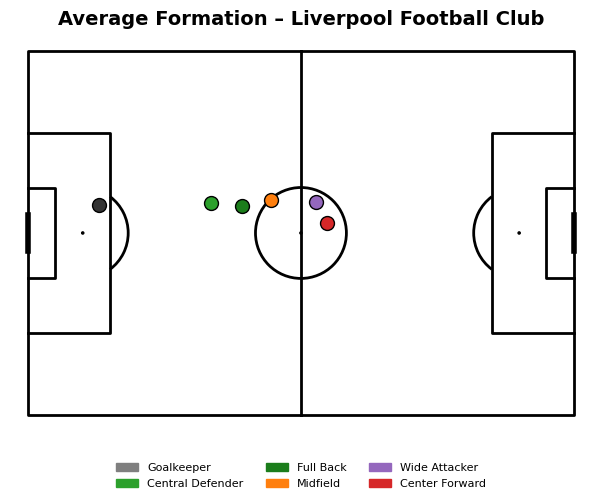

In [49]:
plot_team_formation(role_avg_league, "Liverpool Football Club")


## Step 4) Side-by-Side Comparison of Two Teams

In [50]:
def plot_team_vs_team(role_avg: pd.DataFrame, team1: str, team2: str, dot_size=300):
    """
    Compare average formations of two teams side by side.
    Each position group color appears in the legend (not as text on pitch).
    """
    from matplotlib.lines import Line2D
    from mplsoccer import Pitch
    import matplotlib.pyplot as plt

    def _aggregate(team_name):
        return (role_avg[role_avg["team_name"] == team_name]
                .groupby(["team_name","position_group"])
                [["x_norm","y_norm"]].mean().reset_index())

    t1, t2 = _aggregate(team1), _aggregate(team2)

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=6,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    # Define consistent colors per position group
    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    def _plot(df, ax, title):
        for _, r in df.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c, 
                          edgecolors="black", ax=ax, zorder=3)
        ax.set_title(title, fontsize=12, weight="bold")

    _plot(t1, axs['pitch'][0], team1)
    _plot(t2, axs['pitch'][1], team2)

    # --- Create a shared legend ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=pos,
               markerfacecolor=col, markersize=10, markeredgecolor='black')
        for pos, col in role_colors.items()
    ]

    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=9)

    fig.suptitle("Average Formations – Team Comparison", fontsize=16, weight="bold")
    plt.show()


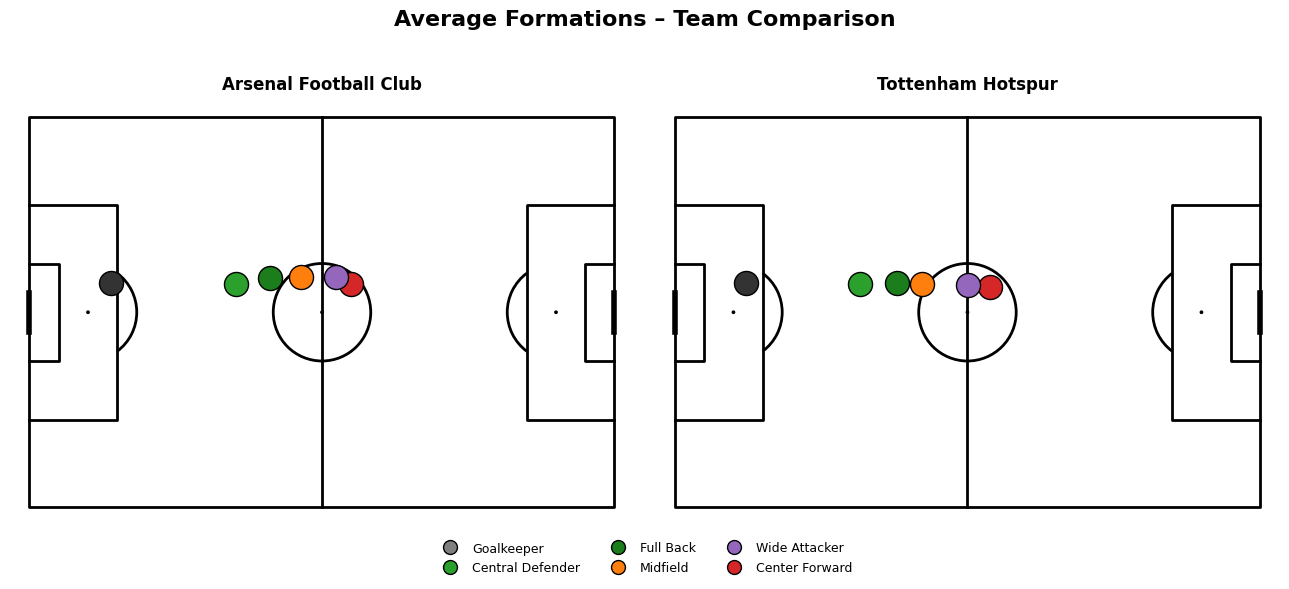

In [51]:
plot_team_vs_team(role_avg_league, "Arsenal Football Club", "Tottenham Hotspur")


## Step 5) Grid of All Teams in the League

In [52]:
def plot_league_formations(role_avg: pd.DataFrame, dot_size=200, ncols=4):
    """
    Grid visualization of all teams' average formations, with legend.
    """
    teams = sorted(role_avg["team_name"].unique())
    nrows = int(np.ceil(len(teams) / ncols))

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=nrows, ncols=ncols, figheight=3*nrows,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    # flatten axes (important!)
    axes = axs['pitch'].flatten()

    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    for idx, team in enumerate(teams):
        ax = axes[idx]
        agg = (role_avg[role_avg["team_name"] == team]
               .groupby(["team_name","position_group"])
               [["x_norm","y_norm"]].mean().reset_index())

        for _, r in agg.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c,
                          edgecolors="black", ax=ax, zorder=3)

        ax.set_title(team, fontsize=9, weight="bold")

    # legend (outside of subplots)
    import matplotlib.patches as mpatches
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               fontsize=8, frameon=False)

    fig.suptitle("Average Formations – League Overview", fontsize=16, weight="bold")
    plt.show()


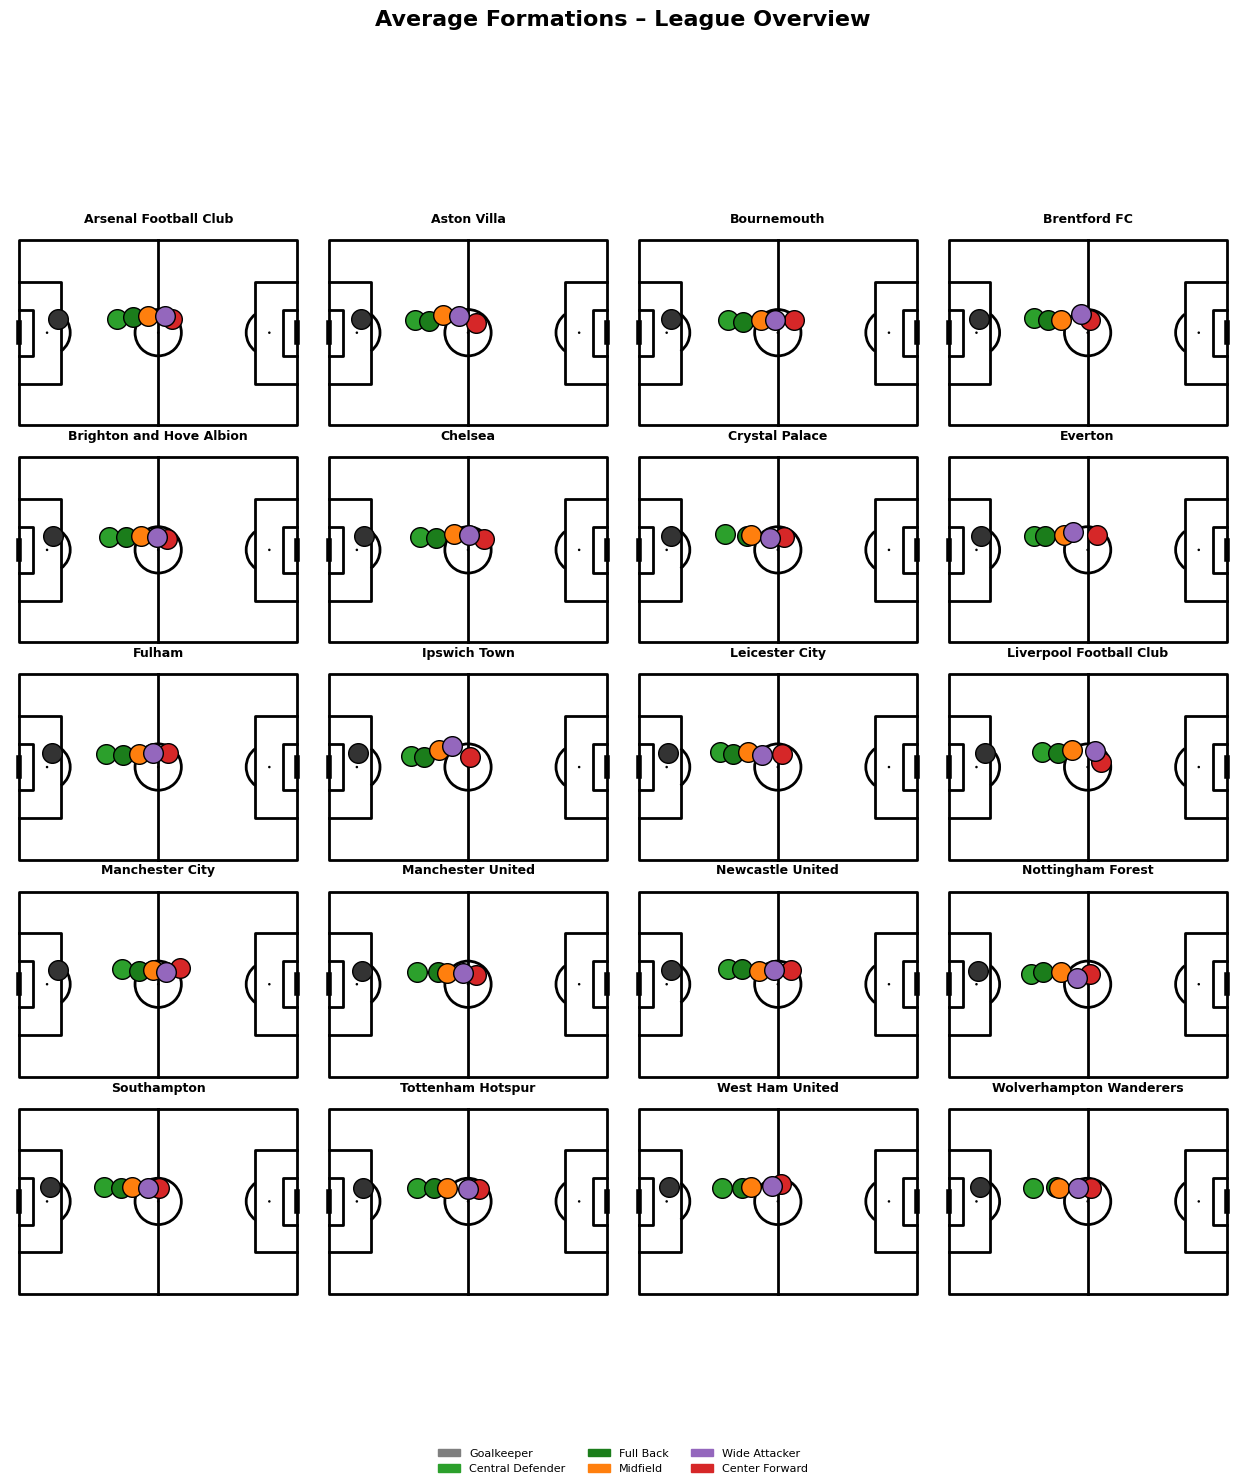

In [53]:
plot_league_formations(role_avg_league, ncols=4)


Practice: filter by phase (attack vs defense) before plotting, so you can present “league-wide attacking formations” vs “league-wide defensive formations”

Now we’ll switch from “single average point per role” to a distributional view per role and then do agglomerative clustering with an EMD-style distance between formations.

# 🔗 Part 2 — Formation Clustering (League-Wide Tactical Structures)

Once the preprocessed tracking data is ready for every match, the next goal is to **discover and visualize recurring team formations** across the entire league.  
In this part, we aim to cluster thousands of frames or half-match snapshots into a small number of **distinct tactical formations** (e.g., 4-4-2, 4-3-3, 3-5-2, etc.).

---

## ⚽ Objective

The idea is to **automatically identify common formation shapes** used by different teams during open play.  
Instead of labeling each match manually, we use clustering algorithms to let the data reveal  
how teams typically arrange themselves spatially.

Each cluster centroid represents an **average player layout** — a data-driven proxy for formations such as 4-4-2 or 4-2-3-1.

---

## 🧱 Key Steps

### 1. Consistent Player Ordering
- To compare formations frame-by-frame, each team’s 11 players must follow the **same ordering convention**.
- We order players **vertically by their `y` position** (top to bottom of the pitch).
- This creates a consistent structure such as `[Player1 (left back), ..., Player11 (right wing)]` in every frame.

### 2. Feature Extraction
- For each match, we compute the **average (x, y)** positions of all 11 players.
- Each formation is represented as a vector of **22 features**:  
  `x1, y1, x2, y2, ..., x11, y11`.
- These become the input features for clustering.

### 3. Clustering Algorithms
We explore multiple clustering methods to uncover formation families:

| Method | Description | Strength |
|--------|--------------|-----------|
| **K-Means** | Partitions formations into K clusters with minimal within-cluster variance. | Fast and interpretable (good baseline). |
| **Gaussian Mixture Models (GMM)** | Models each cluster as a probability distribution; allows soft assignments. | Handles overlapping or flexible formations. |
| **Agglomerative (Hierarchical)** | Iteratively merges similar formations using a distance metric (e.g., Earth Mover’s Distance). | Reveals hierarchical structure between shapes. |

### 4. Cluster Interpretation
- For each cluster, we compute the **centroid formation** (mean player positions).  
- These centroids are visualized on a **105 × 68 m pitch** to interpret shapes.
- We automatically count the number of players along the pitch length to infer human-readable formations such as:
  - `4-4-2`, `4-3-3`, `3-5-2`, etc.
- The **percentage of assignments** per cluster shows how popular each formation is across the league.

---

## 📊 Example Output

| Cluster | Formation Pattern | Share of Samples |
|:--------:|:-----------------|:----------------:|
| 0 | 4-4-2 | 54% |
| 1 | 4-2-3-1 | 22% |
| 2 | 3-5-2 | 12% |
| 3 | 4-3-3 | 8% |
| 4 | 5-4-1 | 4% |

Each cluster represents a *league-wide tactical archetype*.  
By examining which clusters teams belong to most frequently,  
we can infer their **preferred formations** and **strategic tendencies**.

---

## 🧠 Why It Matters

Formation clustering bridges **data science and tactical understanding**.  
It allows analysts, scouts, and researchers to:

- Identify how teams structure themselves in possession or out of possession.
- Track how formations evolve across time or match situations.
- Quantify formation flexibility and similarity between teams.
- Visualize the “tactical DNA” of the league as a whole.

This approach forms the foundation for deeper tactical modeling — such as possession-phase style clustering, player role transitions, and dynamic formation tracking.


## 🧭 Step 1: Consistent Player Ordering for Player-Based Formation Clustering

To compare formations between different matches or teams, we must ensure that
each “feature vector” (the 22 coordinates of 11 players) is **aligned consistently**.

Otherwise, K-Means might think that the *left-back* in one match is the *striker*
in another — making the clustering meaningless.

### ⚽ Why We Need Ordering
Every frame of tracking has 11 outfield players per team.  
Their raw order in the dataset can vary — sometimes player_id 23 appears first,
sometimes last.  
Before clustering, we need to **assign a stable role order**.

### 🧩 How We Do It
For each team and match:
1. Take only **ball-in-play** frames.
2. Compute the **average (x, y)** location of each player.
3. Normalize direction (left-to-right already done ✅).
4. Sort players by their *y-coordinate* (vertical position), and if equal, by *x*.  
   This roughly orders them from **left-back → right-wing**.
5. Flatten the 11 (x, y) pairs → a 22-dimensional vector per team per match.
6. Store this as one sample for clustering.

This gives us comparable formation fingerprints across the entire league.


In [54]:
import pandas as pd
import numpy as np
from pathlib import Path

def extract_team_formation_vector(tr_df: pd.DataFrame) -> pd.DataFrame:
    """
    From one processed match tracking dataframe, extract 1 formation vector per team.
    Returns a DataFrame with:
        [match_id, team_id, team_name, team_short, vector (np.array of length 22)]
    """
    samples = []
    for (match_id, team_id), df_team in tr_df.groupby(["match_id", "team_id"]):
        if df_team["is_ball"].all() or df_team.empty:
            continue
        
        # Only ball-in-play & detected players
        df_play = df_team[df_team["ball_in_play"] & df_team["is_detected"] & (~df_team["is_ball"])].copy()
        if df_play.empty:
            continue
        
        # Average positions per player
        avg_pos = (
            df_play.groupby(["player_id"])
                   [["x_norm", "y_norm"]]
                   .mean()
                   .reset_index()
        )
        
        # Sort players by y then x (left-to-right ordering)
        avg_pos = avg_pos.sort_values(["y_norm", "x_norm"]).reset_index(drop=True)
        
        # If fewer than 11 detected players, skip (incomplete)
        if len(avg_pos) < 11:
            continue
        
        # Take first 11 and flatten to 22D vector
        coords = avg_pos.iloc[:11][["x_norm", "y_norm"]].to_numpy().flatten()
        
        samples.append({
            "match_id": match_id,
            "team_id": team_id,
            "team_name": df_team["team_name"].iloc[0],
            "team_short": df_team["team_short"].iloc[0],
            "formation_vec": coords
        })
    
    return pd.DataFrame(samples)


def build_league_formation_vectors(processed_dir: Path) -> pd.DataFrame:
    """
    Loop over all processed match files and extract formation vectors.
    """
    all_samples = []
    files = list(processed_dir.glob("*.parquet"))
    for f in files:
        try:
            df = pd.read_parquet(f)
            samples = extract_team_formation_vector(df)
            all_samples.append(samples)
            print(f"✅ Processed {f.stem}: {len(samples)} samples")
        except Exception as e:
            print(f"❌ Error in {f.stem}: {e}")
    
    if not all_samples:
        return pd.DataFrame()
    
    return pd.concat(all_samples, ignore_index=True)


In [55]:
# Example usage
formation_vectors = build_league_formation_vectors(PROCESSED_DIR)
print("✅ Total formation samples:", len(formation_vectors))
print(formation_vectors.head())

# Each row now corresponds to a team–match sample
# formation_vectors["formation_vec"][0] → np.array([x1, y1, x2, y2, ..., x11, y11])


✅ Processed 1800191: 2 samples
✅ Processed 1902568: 2 samples
✅ Processed 1902568: 2 samples
✅ Processed 1897172: 2 samples
✅ Processed 1897172: 2 samples
✅ Processed 2004173: 2 samples
✅ Processed 2004173: 2 samples
✅ Processed 2016342: 2 samples
✅ Processed 2016342: 2 samples
✅ Processed 1927295: 2 samples
✅ Processed 1927295: 2 samples
✅ Processed 2014169: 2 samples
✅ Processed 2014169: 2 samples
✅ Processed 1997066: 2 samples
✅ Processed 1997066: 2 samples
✅ Processed 2004054: 2 samples
✅ Processed 2004054: 2 samples
✅ Processed 2006400: 2 samples
✅ Processed 2006400: 2 samples
✅ Processed 1999980: 2 samples
✅ Processed 1832950: 2 samples
✅ Processed 1999980: 2 samples
✅ Processed 1832950: 2 samples
✅ Processed 1729518: 2 samples
✅ Processed 1729518: 2 samples
✅ Processed 1766002: 2 samples
✅ Processed 1766002: 2 samples
✅ Processed 1951807: 2 samples
✅ Processed 1951807: 2 samples
✅ Processed 1967224: 2 samples
✅ Processed 1967224: 2 samples
✅ Processed 1651700: 2 samples
✅ Proces

In [56]:
formation_vectors

,match_id,team_id,team_name,team_short,formation_vec
0,1800191,31.0,Manchester United,Manchester U,"[44.81333198261961, 17.564923831430928, 60.064..."
1,1800191,754.0,Brentford FC,Brentford FC,"[43.09696314916695, 16.2341909263595, 61.57053..."
2,1902568,44.0,Tottenham Hotspur,Tottenham,"[60.53174241042283, 18.299130054917626, 52.294..."
3,1902568,49.0,Chelsea,Chelsea,"[66.65761364914715, 14.617214063737737, 48.566..."
4,1897172,44.0,Tottenham Hotspur,Tottenham,"[44.77798868628052, 16.755549653238898, 63.374..."
...,...,...,...,...,...
751,1683028,44.0,Tottenham Hotspur,Tottenham,"[55.183648439383084, 19.637249431257242, 73.10..."
752,2011368,2.0,Liverpool Football Club,Liverpool,"[70.22155415856533, 16.770496317375294, 52.072..."
753,2011368,37.0,West Ham United,West Ham,"[62.53429003114494, 12.280349185946871, 48.769..."
754,1939715,44.0,Tottenham Hotspur,Tottenham,"[39.46462557753407, 17.603549851228, 59.024880..."


## Step 2: Clustering and Visualizing Team Formation Centroids

Now that we have one 22-dimensional vector per team (11 players × [x, y]),
we can apply a clustering algorithm to group *similar* formation shapes together.

### 🎯 Goal
Discover groups of matches or teams that share similar formation structures,
such as **4-4-2**, **4-3-3**, or **3-5-2**, based only on player positions.

### ⚙️ What We’ll Do
1. **Build a matrix `X`** where each row = one formation (22 features)
2. **Apply a clustering algorithm**  
   - We’ll start with **KMeans**, as it’s fast and easy to interpret  
   - Later you can try **Gaussian Mixture Models (GMM)** for soft clustering
3. **Compute cluster centroids** — each centroid represents the *average formation* of that group
4. **Plot these centroids on a football pitch** using `mplsoccer`,  
   so we can visually interpret the discovered tactical structures.

### 🧩 Why KMeans
KMeans assumes each cluster is roughly spherical in feature space,
which works well here because we’re grouping spatial layouts (not raw metrics).

Each cluster center corresponds to the **typical player layout** for that formation.


In [57]:
from sklearn.cluster import KMeans
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def cluster_formations_kmeans(formation_vectors: pd.DataFrame, n_clusters: int = 6):
    """
    Run KMeans clustering on 22D formation vectors.
    Returns the same dataframe with an added 'cluster' column.
    """
    X = np.stack(formation_vectors["formation_vec"].values)
    
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    formation_vectors["cluster"] = km.fit_predict(X)
    
    return formation_vectors, km


def plot_cluster_centroids(formation_vectors: pd.DataFrame, km: KMeans, n_clusters: int = 6):
    """
    Visualize the centroid (average formation) of each cluster on a pitch.
    """
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    ncols = 3
    nrows = int(np.ceil(n_clusters / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    axs = axs.ravel()

    for cid in range(n_clusters):
        ax = axs[cid]
        pitch.draw(ax=ax)
        
        centroid = km.cluster_centers_[cid]
        xs = centroid[::2]
        ys = centroid[1::2]

        pitch.scatter(xs, ys, s=300, c="#1f77b4", edgecolors="black", ax=ax)
        
        ax.set_title(f"Cluster {cid} ({(formation_vectors['cluster']==cid).mean()*100:.1f}% of samples)",
                     fontsize=12, weight="bold")
        
        # Label player numbers (optional, just 1–11)
        for i, (x, y) in enumerate(zip(xs, ys), start=1):
            ax.text(x, y+1.5, str(i), ha="center", fontsize=8, color="black")
    
    # Hide any unused subplots
    for i in range(n_clusters, len(axs)):
        axs[i].axis("off")

    fig.suptitle("Discovered Formation Clusters (KMeans)", fontsize=18, weight="bold")
    plt.tight_layout()
    plt.show()


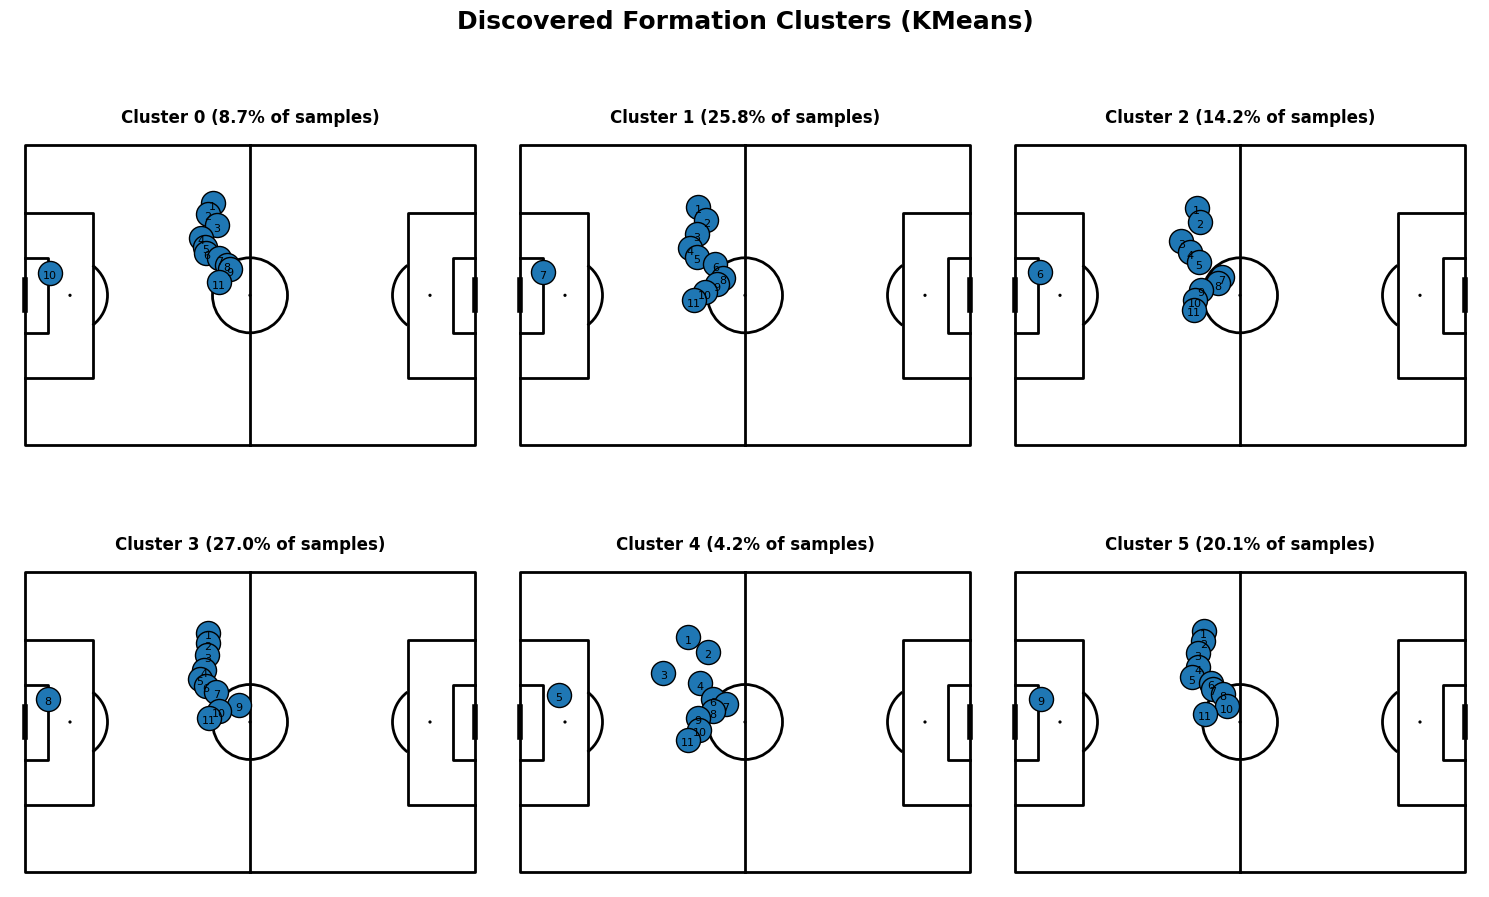

In [58]:
# Example
#formation_vectors = build_league_formation_vectors(PROCESSED_DIR)

# Run clustering
clustered, km_model = cluster_formations_kmeans(formation_vectors, n_clusters=6)

# Visualize the discovered formations
plot_cluster_centroids(clustered, km_model, n_clusters=6)


In [59]:
clustered

,match_id,team_id,team_name,team_short,formation_vec,cluster
0,1800191,31.0,Manchester United,Manchester U,"[44.81333198261961, 17.564923831430928, 60.064...",2
1,1800191,754.0,Brentford FC,Brentford FC,"[43.09696314916695, 16.2341909263595, 61.57053...",3
2,1902568,44.0,Tottenham Hotspur,Tottenham,"[60.53174241042283, 18.299130054917626, 52.294...",1
3,1902568,49.0,Chelsea,Chelsea,"[66.65761364914715, 14.617214063737737, 48.566...",3
4,1897172,44.0,Tottenham Hotspur,Tottenham,"[44.77798868628052, 16.755549653238898, 63.374...",1
...,...,...,...,...,...,...
751,1683028,44.0,Tottenham Hotspur,Tottenham,"[55.183648439383084, 19.637249431257242, 73.10...",3
752,2011368,2.0,Liverpool Football Club,Liverpool,"[70.22155415856533, 16.770496317375294, 52.072...",5
753,2011368,37.0,West Ham United,West Ham,"[62.53429003114494, 12.280349185946871, 48.769...",5
754,1939715,44.0,Tottenham Hotspur,Tottenham,"[39.46462557753407, 17.603549851228, 59.024880...",1


## Per-Team Formation Distribution Analysis

After clustering all team formations (e.g., using K-Means or GMM),  
we can summarize **how frequently each team adopts each formation cluster** across the league.

Each row in the `formation_vector` DataFrame represents a single snapshot (e.g., a half-match or possession phase) and contains:
- `team_name` – the team’s name  
- `match_id` – match identifier  
- `cluster` – the assigned formation cluster (e.g., 0–5)

<Figure size 1200x800 with 0 Axes>

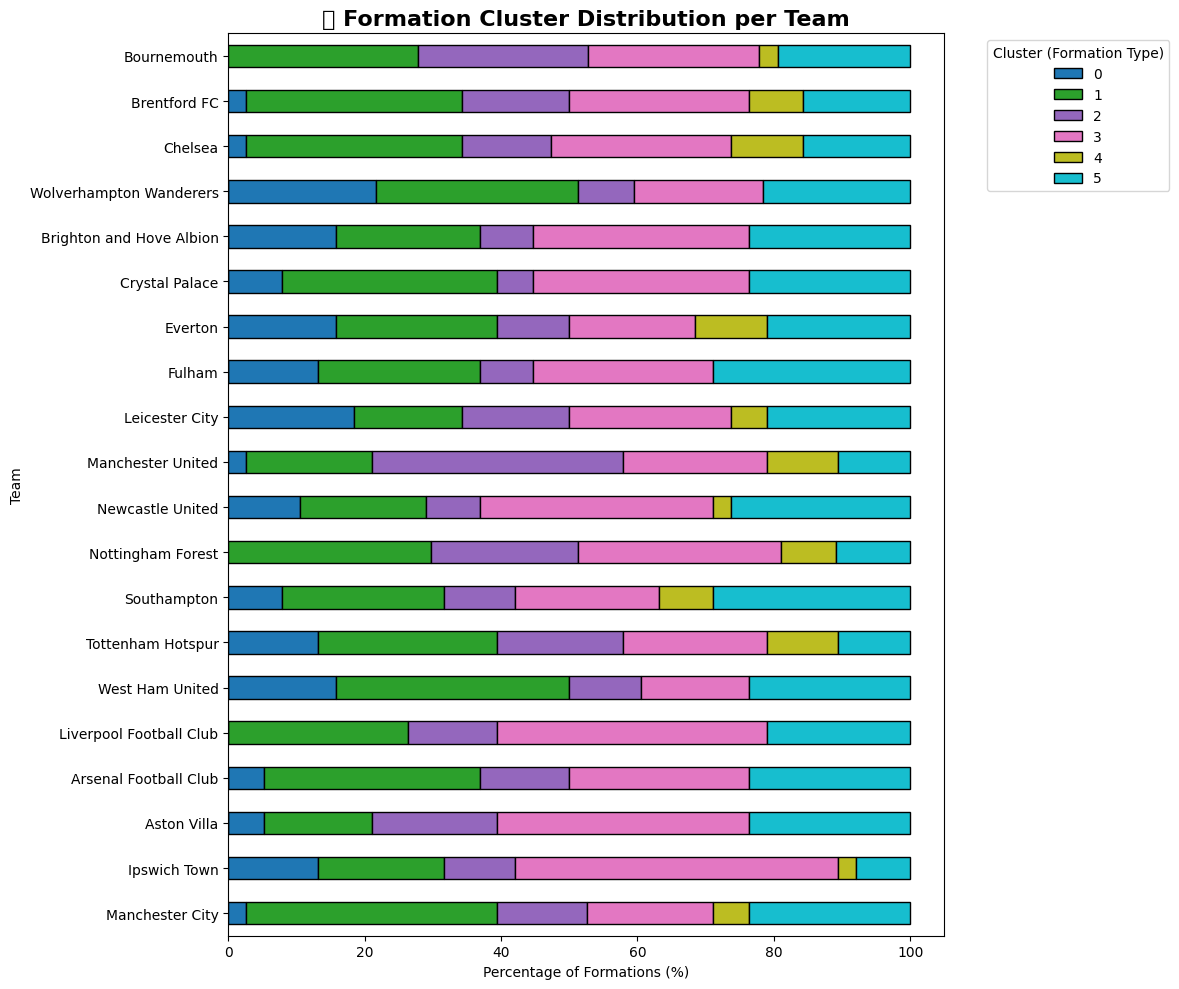

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_team_formation_distribution(formation_vector: pd.DataFrame):
    """
    Compute and visualize how often each team uses each formation cluster.
    """
    # 1️⃣ Count how many times each team appears in each cluster
    cluster_counts = (
        formation_vector.groupby(["team_name", "cluster"])
        .size()
        .reset_index(name="count")
    )

    # 2️⃣ Normalize counts to percentages per team
    cluster_counts["percent"] = (
        cluster_counts.groupby("team_name")["count"]
        .apply(lambda x: 100 * x / x.sum())
        .values
    )

    # 3️⃣ Pivot for visualization
    pivot_df = cluster_counts.pivot(
        index="team_name", columns="cluster", values="percent"
    ).fillna(0)

    # 4️⃣ Sort teams by most common cluster (for better readability)
    pivot_df = pivot_df.loc[
        pivot_df.sum(axis=1).sort_values(ascending=False).index
    ]

    # 5️⃣ Plot stacked bar chart
    plt.figure(figsize=(12, 8))
    pivot_df.plot(
        kind="barh",
        stacked=True,
        colormap="tab10",
        figsize=(12, 10),
        edgecolor="black"
    )

    plt.title("🔎 Formation Cluster Distribution per Team", fontsize=16, weight="bold")
    plt.xlabel("Percentage of Formations (%)")
    plt.ylabel("Team")
    plt.legend(
        title="Cluster (Formation Type)",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=True
    )
    plt.tight_layout()
    plt.show()

# Example usage:
# formation_vector should include: ['team_name', 'match_id', 'cluster']
plot_team_formation_distribution(formation_vectors)


## Cluster interpretation

In [61]:
import pandas as pd
import numpy as np

def export_cluster_centroids(km_model, n_clusters: int, output_path: str = ROOT / "PremierLeague_data/2024/formation_centroids.csv"):
    """
    Extract KMeans cluster centroids and reshape into readable (cluster, player_num, x, y) format.
    """
    centroids = km_model.cluster_centers_  # shape: (n_clusters, 22)
    data = []

    for cid, center in enumerate(centroids):
        xs = center[::2]  # x1, x2, ..., x11
        ys = center[1::2]  # y1, y2, ..., y11
        for pid, (x, y) in enumerate(zip(xs, ys), start=1):
            data.append({"cluster": cid, "player_num": pid, "x": x, "y": y})

    df_centroids = pd.DataFrame(data)
    df_centroids.to_csv(output_path, index=False)
    print(f"💾 Exported {len(df_centroids)} player coordinates ({n_clusters} clusters) → {output_path}")
    return df_centroids

# Example usage:
centroids_df = export_cluster_centroids(km_model, n_clusters=6, output_path=ROOT / "PremierLeague_data/2024/formation_centroids.csv")
centroids_df.head()


💾 Exported 66 player coordinates (6 clusters) → /home/macaco3001/Projectos/Twelve/twelve-deep-learning/PremierLeague_data/2024/formation_centroids.csv


,cluster,player_num,x,y
0,0,1,50.020716,15.442723
1,0,2,48.811247,18.216681
2,0,3,51.223090,21.320392
3,0,4,46.931783,24.628711
4,0,5,48.052549,26.986820


In [62]:
print("\nClusters:", centroids_df["cluster"].unique())



Clusters: [0 1 2 3 4 5]


### Analyze Formation Lines

To infer formations, we’ll group players within each cluster by their x-position.
We’ll detect natural lines (defense, midfield, attack) using clustering on x-values.

**Visualize each cluster’s centroid**
   - Plot the detected lines with different colors (defense = blue, midfield = orange, attack = red) to verify the shape.

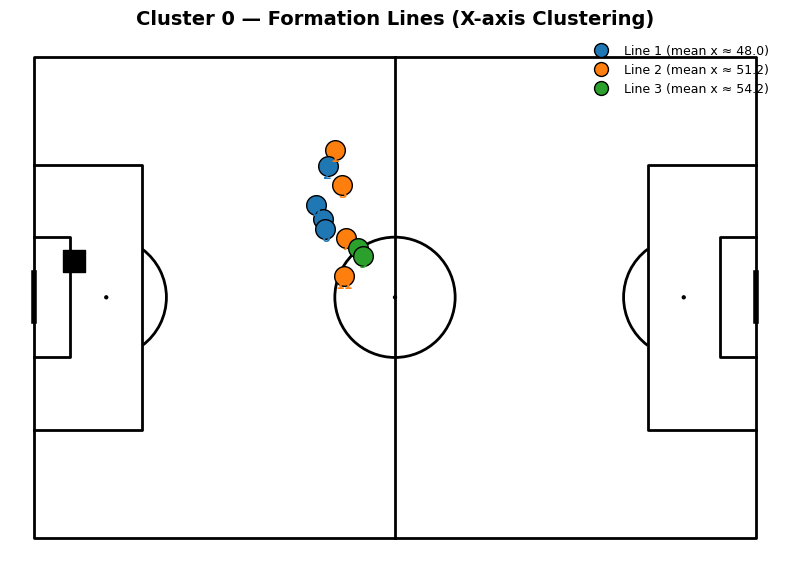

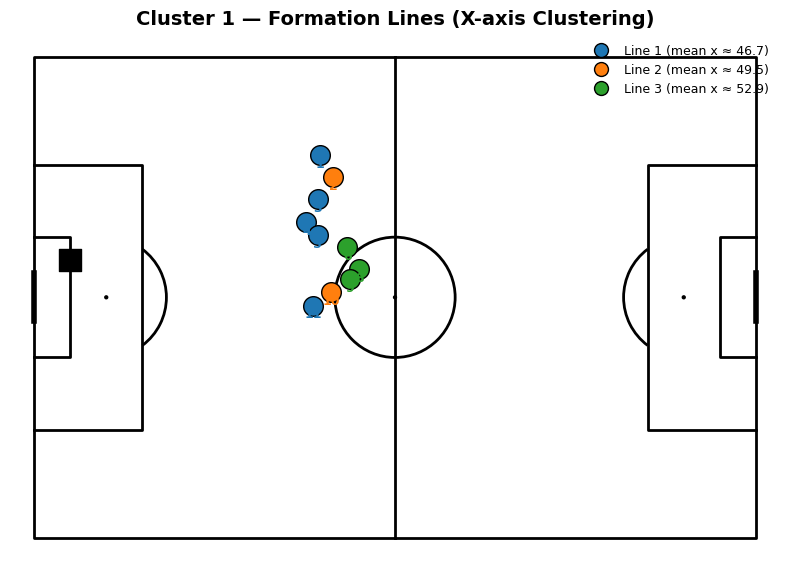

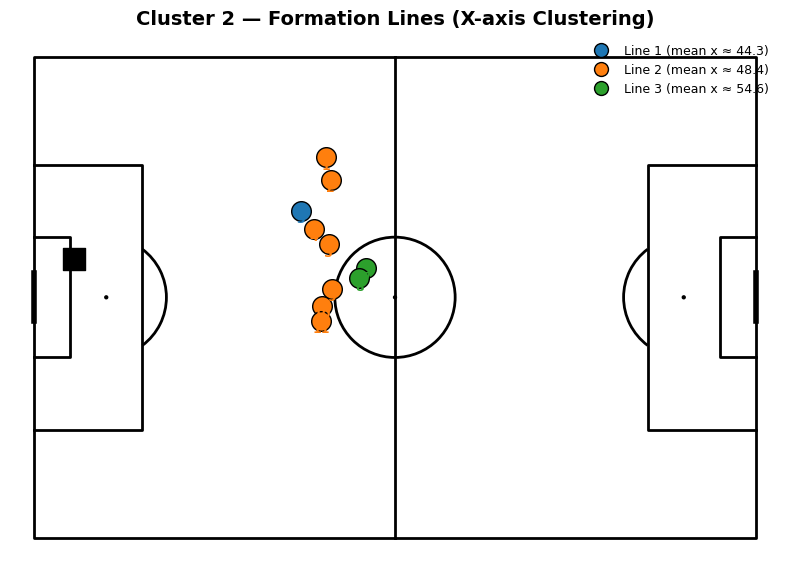

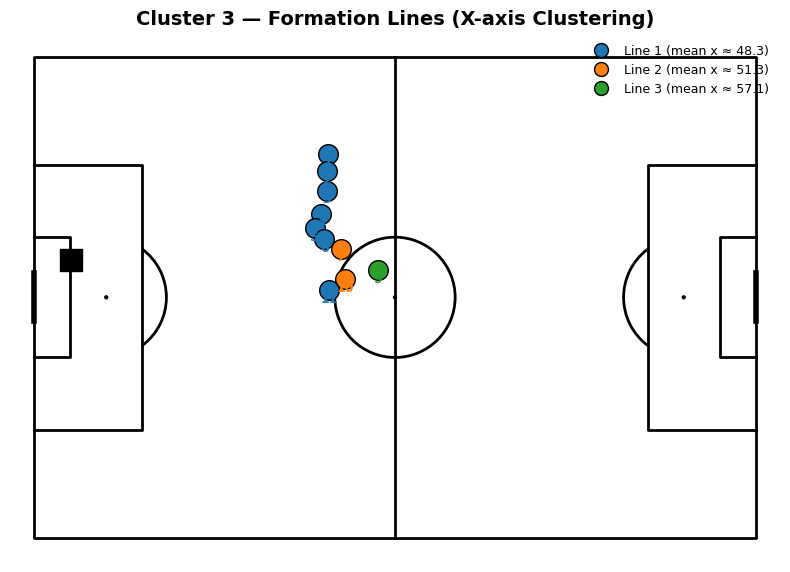

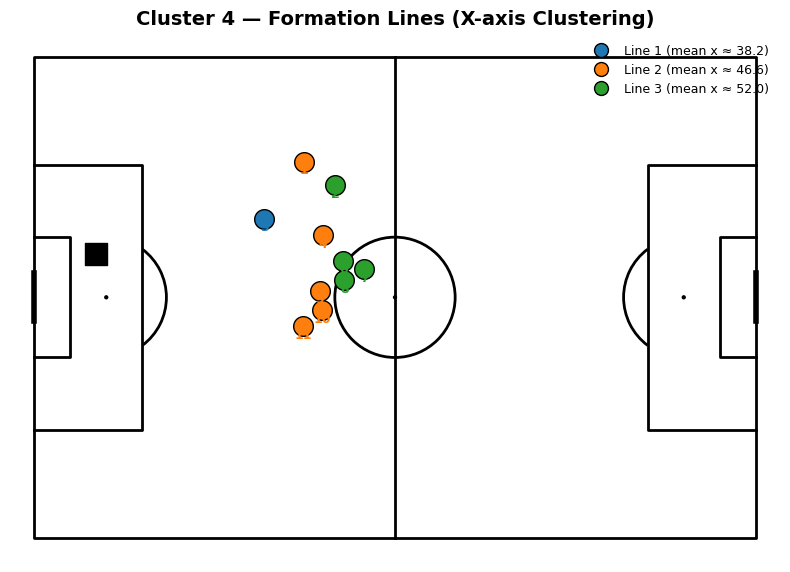

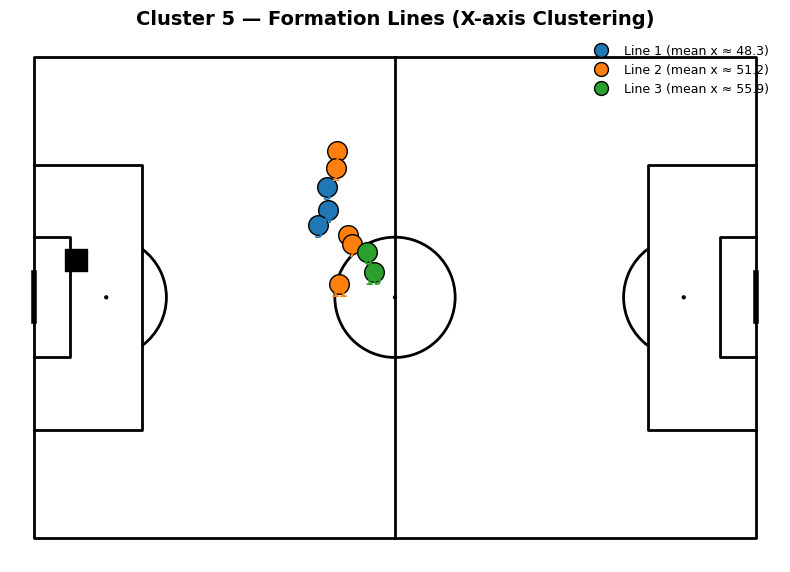

In [63]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd

def plot_detected_lines(df_cluster: pd.DataFrame, n_lines: int = 3, title="Detected Formation (X-axis Clustering)"):
    """
    Detects and visualizes formation lines (defense, midfield, attack) 
    by clustering along the X-axis only, excluding the goalkeeper.
    """
    # Identify goalkeeper as the player closest to own goal (lowest x)
    gk_row = df_cluster.loc[df_cluster["x"].idxmin()]
    df_out = df_cluster[df_cluster["player_num"] != gk_row["player_num"]].copy()

    # --- Clustering along X-axis (pitch length) ---
    X = df_out[["x"]].values
    cl = AgglomerativeClustering(n_clusters=n_lines)
    df_out["line"] = cl.fit_predict(X)

    # Sort lines from defensive to attacking
    line_order = df_out.groupby("line")["x"].mean().sort_values().index.tolist()

    # Assign consistent colors per line
    cmap = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # blue, orange, green
    color_map = {line: cmap[i % len(cmap)] for i, line in enumerate(line_order)}

    # --- Pitch Visualization ---
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(8, 6))

    # Plot goalkeeper
    pitch.scatter(gk_row["x"], gk_row["y"], s=250, c="black", marker="s", ax=ax, label="Goalkeeper")

    # Plot outfield players (color-coded by line)
    for _, row in df_out.iterrows():
        c = color_map[row["line"]]
        pitch.scatter(row["x"], row["y"], s=200, c=c, edgecolors="black", ax=ax)
        ax.text(row["x"], row["y"] + 2, str(int(row["player_num"])), 
                ha="center", fontsize=9, weight="bold", color=c)

    # Add line legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                          label=f"Line {i+1} (mean x ≈ {df_out[df_out['line']==line]['x'].mean():.1f})",
                          markerfacecolor=color_map[line], markersize=10, markeredgecolor="black")
               for i, line in enumerate(line_order)]

    ax.legend(handles=handles, loc="upper right", fontsize=9, frameon=False)
    ax.set_title(title, fontsize=14, weight="bold")

    plt.show()


# Example usage:
df_centroids = pd.read_csv(ROOT / "PremierLeague_data/2024/formation_centroids.csv")
for c in sorted(df_centroids["cluster"].unique()):
    df_c = df_centroids[df_centroids["cluster"] == c]
    plot_detected_lines(df_c, n_lines=3, title=f"Cluster {c} — Formation Lines (X-axis Clustering)")


### The below code automatically detects the number of formation lines (3 or 4) based on how players are distributed along the x-axis —
so, for example, a 4-2-3-1 may show four vertical layers, while a 4-4-2 shows three.

In [64]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

def plot_detected_lines(df_cluster: pd.DataFrame, title="Detected Formation (Adaptive Lines)"):
    """
    Detect and visualize formation lines (defense–midfield–attack)
    using adaptive clustering on the X-axis (pitch length).
    
    Automatically determines whether 3 or 4 vertical lines exist.
    Goalkeeper is excluded before clustering.
    """
    # --- Exclude goalkeeper (lowest x = closest to own goal) ---
    gk_row = df_cluster.loc[df_cluster["x"].idxmin()]
    df_out = df_cluster[df_cluster["player_num"] != gk_row["player_num"]].copy()

    # --- X-axis coordinates for clustering ---
    X = df_out[["x"]].values

    # --- Adaptive selection of number of lines (3 or 4) ---
    sil_scores = {}
    for k in [3, 4]:
        cl = AgglomerativeClustering(n_clusters=k)
        labels = cl.fit_predict(X)
        if len(set(labels)) > 1:
            sil_scores[k] = silhouette_score(X, labels)
        else:
            sil_scores[k] = -1  # invalid case

    best_n = max(sil_scores, key=sil_scores.get)
    print(f"Detected {best_n} formation lines (silhouette={sil_scores[best_n]:.3f})")

    # --- Final clustering ---
    cl_final = AgglomerativeClustering(n_clusters=best_n)
    df_out["line"] = cl_final.fit_predict(X)

    # --- Sort lines from defense to attack ---
    line_order = df_out.groupby("line")["x"].mean().sort_values().index.tolist()

    # --- Assign colors ---
    cmap = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # up to 4 lines
    color_map = {line: cmap[i % len(cmap)] for i, line in enumerate(line_order)}

    # --- Pitch setup ---
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(8, 6))

    # --- Plot goalkeeper ---
    pitch.scatter(gk_row["x"], gk_row["y"], s=250, c="black", marker="s", ax=ax, label="Goalkeeper")

    # --- Plot outfield players ---
    for _, row in df_out.iterrows():
        c = color_map[row["line"]]
        pitch.scatter(row["x"], row["y"], s=200, c=c, edgecolors="black", ax=ax)
        ax.text(row["x"], row["y"] + 2, str(int(row["player_num"])),
                ha="center", fontsize=9, weight="bold", color=c)

    # --- Add vertical reference lines for each formation layer ---
    for line_id, x_mean in df_out.groupby("line")["x"].mean().items():
        ax.axvline(x_mean, color=color_map[line_id], linestyle="--", alpha=0.7, lw=1.5)

    # --- Legend ---
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          label=f"Line {i+1} (x̄ ≈ {df_out[df_out['line']==line]['x'].mean():.1f} m)",
                          markerfacecolor=color_map[line], markersize=10,
                          markeredgecolor="black")
               for i, line in enumerate(line_order)]
    ax.legend(handles=handles, loc="upper right", fontsize=9, frameon=False)

    ax.set_title(title, fontsize=14, weight="bold")
    plt.show()


Detected 3 formation lines (silhouette=0.648)


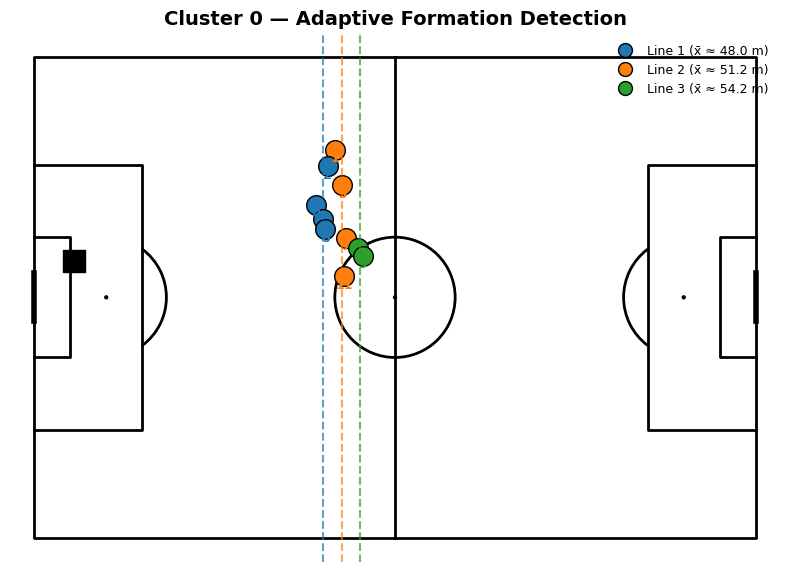

Detected 3 formation lines (silhouette=0.673)


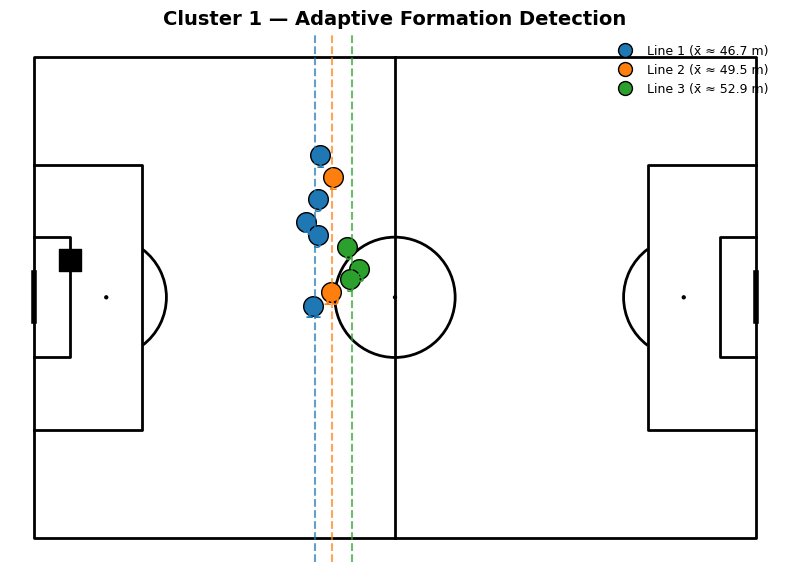

Detected 3 formation lines (silhouette=0.609)


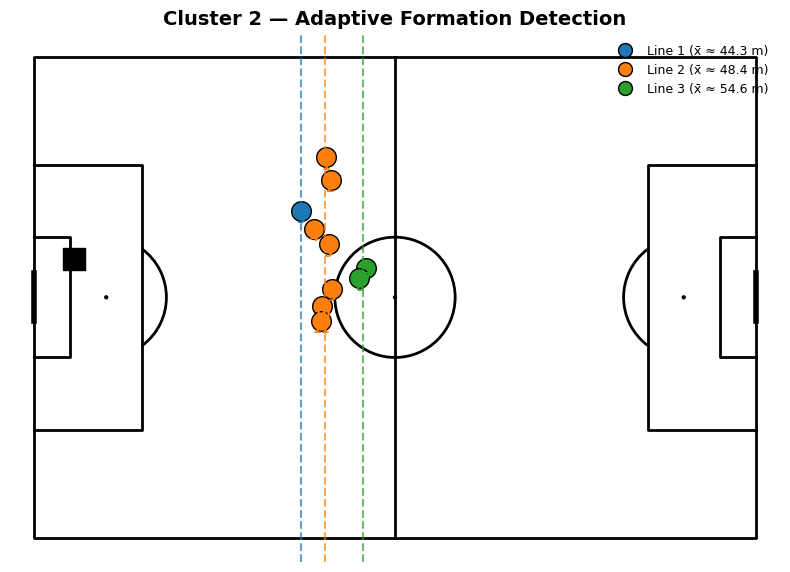

Detected 3 formation lines (silhouette=0.648)


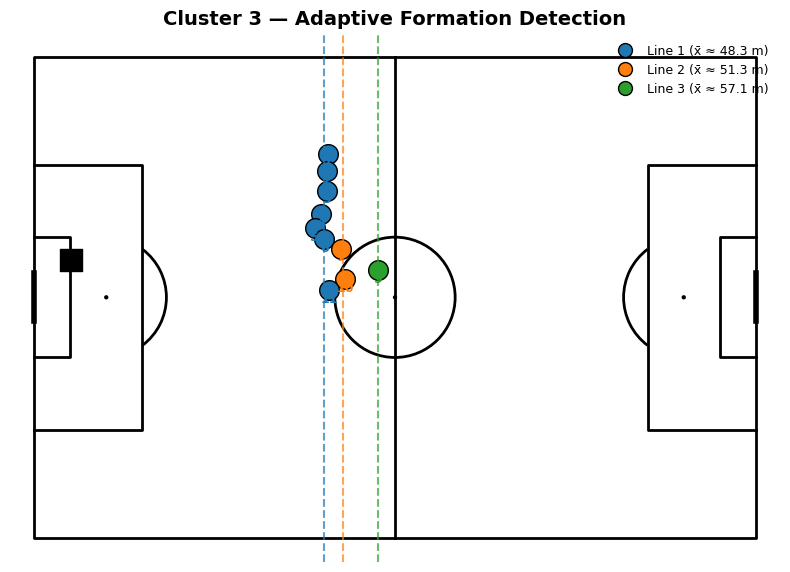

Detected 3 formation lines (silhouette=0.524)


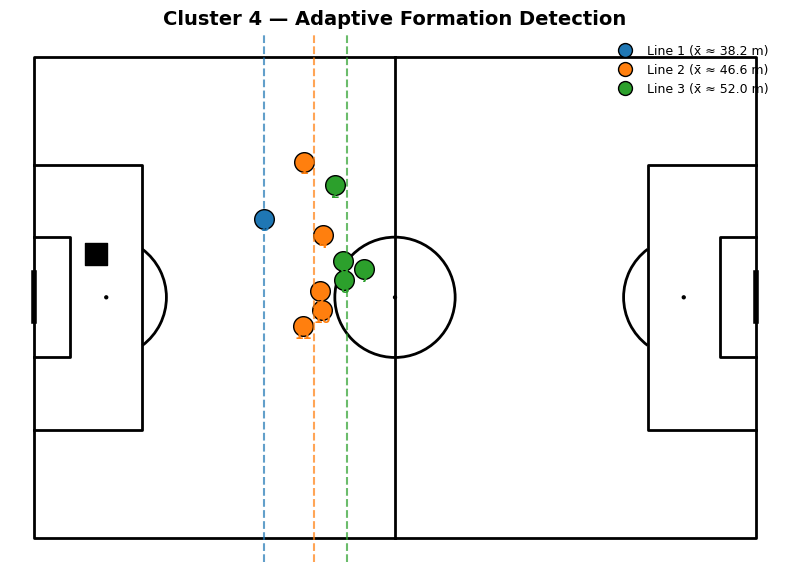

Detected 4 formation lines (silhouette=0.684)


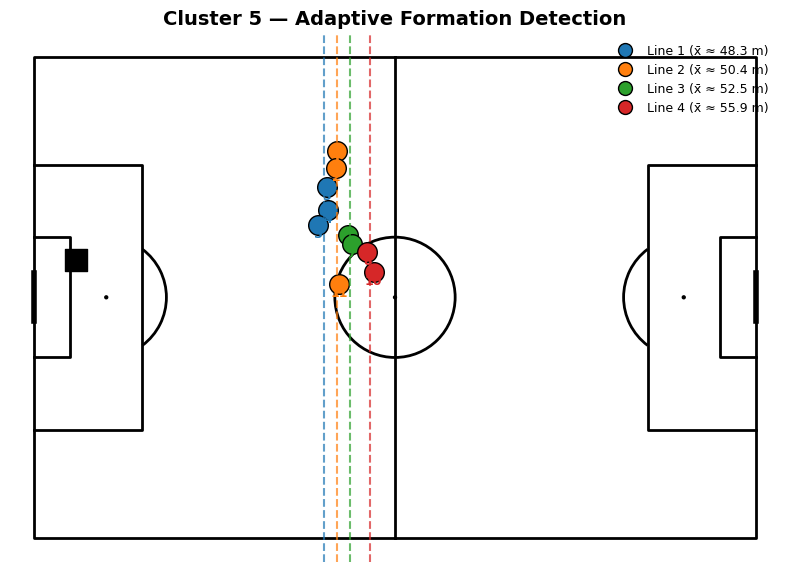

In [65]:
df_centroids = pd.read_csv(ROOT / "PremierLeague_data/2024/formation_centroids.csv")
for c in sorted(df_centroids["cluster"].unique()):
    df_c = df_centroids[df_centroids["cluster"] == c]
    plot_detected_lines(df_c, title=f"Cluster {c} — Adaptive Formation Detection")


# 🤖 Step 7 — Comparing K-Means and GMM for Formation Discovery

Now that we’ve represented every team’s formation numerically (11 player centroids per match),
we can cluster them to identify **typical tactical structures** such as:
- `4-3-3` (wide attacking front)
- `4-2-3-1` (compact midfield)
- `3-5-2` (back three with wing-backs)

---

### ⚙️ Why compare K-Means and GMM?

| Method | Type | What it assumes | Best for |
|--------|------|-----------------|-----------|
| **K-Means** | Hard clustering | Each cluster has spherical shape, equal variance | Clear, rigid formation boundaries |
| **GMM (Gaussian Mixture Model)** | Soft clustering | Each cluster has its own variance & orientation | Flexible, overlapping tactical variations |

---

### 💡 Interpretation
- K-Means assigns **one formation label** per sample.
- GMM provides **probabilistic membership** (e.g., 80% 4-3-3, 20% 4-2-3-1),  
  capturing hybrid shapes or transitions between systems.

We’ll visualize both approaches to see how stable each clustering is and how they differ in how they group team shapes.


In [66]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# === Load your formation dataset (each centroid set flattened to 22D vector) ===
df_centroids = pd.read_csv("formation_centroids.csv")

# Flatten each cluster’s x,y coordinates (player_num 1–11)
def flatten_formation(df):
    df = df.sort_values("player_num")
    return np.concatenate([df["x"].values, df["y"].values])

# Build X matrix for clustering
X = np.vstack([
    flatten_formation(df_centroids[df_centroids["cluster"] == c])
    for c in sorted(df_centroids["cluster"].unique())
])

# === Fit K-Means ===
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)

# === Fit GMM ===
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)

# === Combine Results ===
compare_df = pd.DataFrame({
    "sample": np.arange(len(X)),
    "KMeans_cluster": k_labels,
    "GMM_cluster": gmm_labels,
    "GMM_entropy": -np.sum(gmm_probs * np.log(gmm_probs + 1e-9), axis=1)
})

print("✅ Comparison table:")
display(compare_df.head())

# === Visualize clusters side-by-side ===
pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
              pitch_color='white', line_color='black')

fig, axes = plt.subplots(2, n_clusters, figsize=(18, 7))
fig.suptitle("K-Means vs GMM Formation Clusters", fontsize=16, weight="bold")

for i in range(n_clusters):
    for model, ax, title, labels in [
        ("KMeans", axes[0, i], "K-Means", k_labels),
        ("GMM", axes[1, i], "GMM", gmm_labels),
    ]:
        pitch.draw(ax=ax)
        mask = labels == i
        for j, c in enumerate(np.where(mask)[0]):
            df = df_centroids[df_centroids["cluster"] == c]
            ax.scatter(df["x"], df["y"], s=80, alpha=0.5, label=f"Sample {c}")
        ax.set_title(f"{title} Cluster {i}", fontsize=10)

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'formation_centroids.csv'

# 🧠 Why K-Means and GMM Are Producing the Same Results
### ⚙️ 1. You only have one "mean" formation per cluster
Your input matrix `X` was built from cluster centroids — that means you’re clustering already-averaged shapes.  
There’s not enough variance in the data for GMM to find multiple overlapping distributions.

So both K-Means and GMM "see" the same 6 points in formation space — and naturally, assign one cluster per point.

---

### 🎯 2. Both models are centroid-based when variance ≈ 0
- **K-Means** finds hard boundaries between cluster centers.
- **GMM** models ellipses around centers (soft boundaries).

If your samples are too few or perfectly separated, both reduce to the same solution —  
each centroid becomes one cluster, and there’s no soft overlap to model.

---

### ⚽ 3. The football context: You're not clustering possessions or match halves
Formations don’t change much within one average — but if you cluster **many per-team formations**  
(e.g., each *half* of each match, or *each team’s average formation per match*),  
you’ll see GMM discovering:
- Hybrid systems (e.g. between *4-3-3* and *4-2-3-1*)
- Asymmetrical defensive vs attacking structures
- Shape drift (variability in line spacing)

That’s where GMM becomes interesting.


## 🧩 Part 3 — Possession-Level Clustering (Playing Style Discovery)

### 🎯 Goal
Discover how teams construct attacks and uncover different **offensive playing styles** such as:
- *Direct transitions*  
- *Tiki-taka buildup*  
- *Counterpressing attacks*  
- *Wing overloads*, etc.

### 🧠 Key Concepts
- Possession segmentation  
- Feature engineering at possession level (e.g., pass length, xT, pressure, duration)  
- Feature normalization and dimensionality reduction (PCA)  
- KMeans clustering  
- Interpretation of clusters as tactical styles

### ⚙️ Practical Steps
1. **Create possession-level features** from event data.  
2. **Apply PCA** and visualize explained variance.  
3. **Cluster possessions** with KMeans to find groups of similar styles.  
4. **Visualize team distributions** across clusters (% of possessions per style).  
5. **Interpret clusters** in football terms (e.g., Cluster 3 = “Direct Long Ball Transitions”).

### 💡 Outcome
An understanding of how machine learning can uncover underlying playing styles from high-frequency football data.

## Freeze Frames generation

We need to now merge tracking data to dynamic events and meta data to generate freeze frames:

In [67]:
import os, json
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
BASE_DIR = ROOT / "PremierLeague_data/2024"
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"
TRACKING_DIR = BASE_DIR / "tracking"

# Pitch constants (SkillCorner → FIFA/mplsoccer scale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105, 68

# =====================================================
# Step 1. Build matches.parquet (if missing)
# =====================================================
matches_file = BASE_DIR / "matches.parquet"
if not matches_file.exists():
    records = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        # Try to enrich with meta
        meta_path = META_DIR / f"{match_id}.json"
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        else:
            home_team, away_team = None, None
        records.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(records)
    df_matches.to_parquet(matches_file, index=False)
    print(f"✅ Built matches.parquet with {len(df_matches)} matches")
else:
    df_matches = pd.read_parquet(matches_file)
    print(f"✅ Loaded matches.parquet with {len(df_matches)} matches")

# =====================================================
# Step 2. Helper: rescale coords
# =====================================================
def rescale_to_pitch(df,
                     x_min=X_MIN, x_max=X_MAX,
                     y_min=Y_MIN, y_max=Y_MAX,
                     target_x=PITCH_LENGTH, target_y=PITCH_WIDTH):
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    if "x_end" in df.columns and "y_end" in df.columns:
        df["x_end_rescaled"] = (df["x_end"] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df["y_end"] - y_min) / (y_max - y_min) * target_y
    return df

# =====================================================
# Step 3. Helper: load meta mapping
# =====================================================
def load_meta_mapping(match_id: int):
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        return pd.DataFrame()

    with open(fpath, "r") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]
    records = []
    for p in meta.get("players", []):
        if "id" not in p:
            continue
        team_name = home_team["name"] if p["team_id"] == home_team["id"] else away_team["name"]
        team_shortname = home_team["short_name"] if p["team_id"] == home_team["id"] else away_team["short_name"]

        records.append({
            "match_id": meta["id"],
            "player_id_meta": p["id"],
            "player_short_name": p.get("short_name"),
            "player_team_id": p["team_id"],
            "player_team_name": team_name,
            "player_team_shortname": team_shortname,
            "player_position_group": p["player_role"]["position_group"] if p.get("player_role") else None,
            "player_role": p["player_role"]["name"] if p.get("player_role") else None
        })
    return pd.DataFrame(records)

# =====================================================
# Step 4. Build freeze frames for all matches
# =====================================================
all_freeze_frames = []

for match_id in df_matches["id"].values:
    # Load events
    try:
        df_events = pd.read_parquet(DYNAMIC_DIR / f"{match_id}.parquet")
    except:
        print(f"⚠️ No events for match {match_id}")
        continue

    # Only possession events
    df_events_pos = df_events[df_events["event_type"] == "player_possession"]

    # Event columns we care about
    df_events_end = df_events_pos[[
        "event_id","match_id","frame_start","frame_end",
        "time_start","time_end","team_id","attacking_side",
        "player_id","player_name","team_shortname",
        "start_type","end_type","x_start","y_start","x_end","y_end"
    ]]

    # Load tracking JSON
    fpath = TRACKING_DIR / f"{match_id}.json"
    if not fpath.exists():
        print(f"⚠️ No tracking for match {match_id}")
        continue
    with open(fpath, "r") as f:
        tracking_data = json.load(f)

    # Collect freeze frames
    frames = set(df_events_end["frame_start"].to_list() + df_events_end["frame_end"].to_list())
    custom_data = []
    for d in tracking_data:
        if d.get("frame") in frames and d.get("timestamp") is not None:
            for p in d["player_data"]:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": p.get("player_id"),
                    "is_detected": p.get("is_detected"),
                    "is_ball": False,
                    "x": p.get("x"),
                    "y": p.get("y")
                })
            # Ball
            ball = d.get("ball_data")
            if ball and ball.get("is_detected") is not None:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": -1,
                    "is_detected": ball.get("is_detected"),
                    "is_ball": True,
                    "x": ball.get("x"),
                    "y": ball.get("y")
                })

    df_frames = pd.DataFrame(custom_data)

    # Merge with events
    df_freeze = df_frames.merge(
        df_events_end,
        left_on=["match_id","frame"],
        right_on=["match_id","frame_end"],
        how="inner"
    ).rename(columns={"player_id": "player_id_event"})

    # Merge with meta
    df_meta = load_meta_mapping(match_id)
    if not df_meta.empty:
        df_freeze = df_freeze.merge(
            df_meta,
            left_on=["match_id","player_id_tracking"],
            right_on=["match_id","player_id_meta"],
            how="left"
        )

    # Rescale
    df_freeze = rescale_to_pitch(df_freeze)

    all_freeze_frames.append(df_freeze)

# =====================================================
# Step 5. Final dataset
# =====================================================
if all_freeze_frames:
    df_freeze_start_enriched = pd.concat(all_freeze_frames, ignore_index=True)
else:
    df_freeze_start_enriched = pd.DataFrame()

print("✅ Final freeze-frame shape:", df_freeze_start_enriched.shape)
df_freeze_start_enriched.head()
#df_freeze_start_enriched.to_parquet(ROOT / "PremierLeague_data/Pl_freeze_frames.parquet")

✅ Loaded matches.parquet with 378 matches
✅ Final freeze-frame shape: (8329949, 36)
✅ Final freeze-frame shape: (8329949, 36)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1800191,00:00:03.10,41,1,19054,False,False,-41.02,0.39,8_0,...,M. Flekken,754.0,Brentford FC,Brentford FC,Other,Goalkeeper,11.085577,34.39,53.257212,33.43
1,1800191,00:00:03.10,41,1,24638,True,False,-16.65,-6.02,8_0,...,N. Collins,754.0,Brentford FC,Brentford FC,Central Defender,Right Center Back,35.689904,27.98,53.257212,33.43
2,1800191,00:00:03.10,41,1,24556,True,False,-16.71,6.33,8_0,...,E. Pinnock,754.0,Brentford FC,Brentford FC,Central Defender,Left Center Back,35.629327,40.33,53.257212,33.43
3,1800191,00:00:03.10,41,1,14488,True,False,-14.45,-20.75,8_0,...,S. van den Berg,754.0,Brentford FC,Brentford FC,Full Back,Right Back,37.911058,13.25,53.257212,33.43
4,1800191,00:00:03.10,41,1,12012,True,False,-16.27,20.63,8_0,...,K. Ajer,754.0,Brentford FC,Brentford FC,Full Back,Left Back,36.073558,54.63,53.257212,33.43


In [69]:
df_freeze_start_enriched.to_parquet(ROOT / "PremierLeague_data/Pl_freeze_frames.parquet")

In [70]:
df_freeze= pd.read_parquet(ROOT / "PremierLeague_data/Pl_freeze_frames.parquet")

In [71]:
df_freeze

,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1800191,00:00:03.10,41,1,19054,False,False,-41.02,0.39,8_0,...,M. Flekken,754.0,Brentford FC,Brentford FC,Other,Goalkeeper,11.085577,34.39,53.257212,33.43
1,1800191,00:00:03.10,41,1,24638,True,False,-16.65,-6.02,8_0,...,N. Collins,754.0,Brentford FC,Brentford FC,Central Defender,Right Center Back,35.689904,27.98,53.257212,33.43
2,1800191,00:00:03.10,41,1,24556,True,False,-16.71,6.33,8_0,...,E. Pinnock,754.0,Brentford FC,Brentford FC,Central Defender,Left Center Back,35.629327,40.33,53.257212,33.43
3,1800191,00:00:03.10,41,1,14488,True,False,-14.45,-20.75,8_0,...,S. van den Berg,754.0,Brentford FC,Brentford FC,Full Back,Right Back,37.911058,13.25,53.257212,33.43
4,1800191,00:00:03.10,41,1,12012,True,False,-16.27,20.63,8_0,...,K. Ajer,754.0,Brentford FC,Brentford FC,Full Back,Left Back,36.073558,54.63,53.257212,33.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8329944,1939715,01:40:45.10,62711,2,32567,False,False,-2.55,-5.18,8_907,...,P. Sarr,44.0,Tottenham Hotspur,Tottenham,Midfield,Right Midfield,49.925481,28.82,96.549519,65.61
8329945,1939715,01:40:45.10,62711,2,24053,False,False,-20.64,-4.96,8_907,...,D. Kulusevski,44.0,Tottenham Hotspur,Tottenham,Midfield,Attacking Midfield,31.661538,29.04,96.549519,65.61
8329946,1939715,01:40:45.10,62711,2,10391,False,False,-43.63,-31.61,8_907,...,T. Werner,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Left Winger,8.450481,2.39,96.549519,65.61
8329947,1939715,01:40:45.10,62711,2,2816,True,False,-30.51,-4.72,8_907,...,D. Solanke,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,21.696635,29.28,96.549519,65.61


In [72]:
df_freeze.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_tracking',
       'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start',
       'frame_end', 'time_start', 'time_end', 'team_id', 'attacking_side',
       'player_id_event', 'player_name', 'team_shortname', 'start_type',
       'end_type', 'x_start', 'y_start', 'x_end', 'y_end', 'player_id_meta',
       'player_short_name', 'player_team_id', 'player_team_name',
       'player_team_shortname', 'player_position_group', 'player_role',
       'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled'],
      dtype='object')

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [74]:
# Group events by possession_id
# (if you don’t have possession_id, you can reconstruct from event sequence)
if "possession_id" in df.columns:
    df_possessions = df.groupby(["match_id", "possession_id"]).agg({
        "event_id": "count",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "frame_start": "min",
        "frame_end": "max",
        "team_id": "first",
        "player_team_name": "first"
    }).reset_index()
else:
    print("⚠️ possession_id not found — use event grouping rules instead")

⚠️ possession_id not found — use event grouping rules instead


## ⚽️ Tutorial: Building Possessions from Events

We’ll work on the events table, not freeze-frames, because possession boundaries are event-based.

👉 The general rule you suggested:

A possession continues until the opponent team performs ≥2 consecutive actions.

That break → a new possession starts.


In [75]:
# Example: load all events into one big DataFrame
all_events = []
for f in DYNAMIC_DIR.glob("*.parquet"):
    df = pd.read_parquet(f)
    df["match_id"] = int(f.stem)
    all_events.append(df)

df_events_all = pd.concat(all_events, ignore_index=True)
print("All events:", df_events_all.shape)


All events: (1811078, 294)


In [76]:
# Step 2. Sort Events in Time
df_events_all = df_events_all.sort_values(
    ["match_id", "period", "frame_start"]
).reset_index(drop=True)


# Step 3. Construct Possession IDs
def assign_possessions(events_df):
    events_df = events_df.copy()
    possession_ids = []
    current_possession = 0
    last_team = None
    opponent_count = 0

    for idx, row in events_df.iterrows():
        team = row["team_id"]

        if last_team is None:
            # Start first possession
            current_possession += 1
            possession_ids.append(current_possession)
            last_team = team
            opponent_count = 0
            continue

        if team == last_team:
            # Same team continues possession
            possession_ids.append(current_possession)
            opponent_count = 0
        else:
            # Opponent action
            opponent_count += 1
            if opponent_count >= 2:
                # Switch possession
                current_possession += 1
                possession_ids.append(current_possession)
                last_team = team
                opponent_count = 0
            else:
                # Still count as previous possession
                possession_ids.append(current_possession)

    events_df["possession_id"] = possession_ids
    return events_df

df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


/tmp/ipykernel_14371/3007072774.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


In [77]:
df_events_all[["match_id","period","frame_start","frame_end", "team_id","team_shortname","event_type","possession_id"]].iloc[8:30]


,match_id,period,frame_start,frame_end,team_id,team_shortname,event_type,possession_id
8,1650385,1,87,124,48,Fulham,player_possession,1
9,1650385,1,87,90,48,Fulham,passing_option,1
10,1650385,1,90,124,48,Fulham,passing_option,1
11,1650385,1,99,120,48,Fulham,passing_option,1
12,1650385,1,101,124,31,Manchester U,on_ball_engagement,1
13,1650385,1,119,124,48,Fulham,passing_option,1
14,1650385,1,119,124,48,Fulham,passing_option,1
15,1650385,1,125,156,48,Fulham,off_ball_run,1
16,1650385,1,126,152,31,Manchester U,on_ball_engagement,1
17,1650385,1,143,152,48,Fulham,player_possession,1


In [78]:
df_freeze = df_freeze.merge(
    df_events_all[["match_id","event_id","period","possession_id"]],
    on=["match_id","event_id"], how="left"
)

## Tutorial Notebook: Playing Style & Role Representations

In [79]:
# 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

In [80]:
df_freeze.columns

Index(['match_id', 'time', 'frame', 'period_x', 'player_id_tracking',
       'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start',
       'frame_end', 'time_start', 'time_end', 'team_id', 'attacking_side',
       'player_id_event', 'player_name', 'team_shortname', 'start_type',
       'end_type', 'x_start', 'y_start', 'x_end', 'y_end', 'player_id_meta',
       'player_short_name', 'player_team_id', 'player_team_name',
       'player_team_shortname', 'player_position_group', 'player_role',
       'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled',
       'period_y', 'possession_id'],
      dtype='object')

## Understand Coordinate Systems

We have two coordinate sources:

Event data → x_start, y_start, x_end, y_end

Range: roughly –60 to +60 (as seen from your stats)

These are likely SkillCorner coordinates, centered around (0, 0).
→ The pitch center is 0, left goal ≈ –52, right goal ≈ +52.

Tracking data → x, y

Same range and meaning (also centered pitch coordinates).


In [81]:
df_freeze.x_start.describe()

count    8.329949e+06
mean    -3.249549e+00
std      2.479519e+01
min     -5.601000e+01
25%     -2.280000e+01
50%     -3.070000e+00
75%      1.626000e+01
max      5.733000e+01
Name: x_start, dtype: float64

In [82]:
df_freeze.x.describe()

count    8.329949e+06
mean    -2.618674e-01
std      2.451214e+01
min     -6.295000e+01
25%     -1.947000e+01
50%     -3.700000e-01
75%      1.884000e+01
max      6.287000e+01
Name: x, dtype: float64


✅ That’s good — they’re on the same coordinate system (SkillCorner system).

In [83]:
# Apply rescaling:

PITCH_LENGTH, PITCH_WIDTH = 105, 68
X_MIN, X_MAX, Y_MIN, Y_MAX = -52, 52, -34, 34

df_freeze["x_rescaled"] = (df_freeze["x"] - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH
df_freeze["y_rescaled"] = (df_freeze["y"] - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH
df_freeze["x_start_rescaled"] = (df_freeze["x_start"] - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH
df_freeze["y_start_rescaled"] = (df_freeze["y_start"] - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH
df_freeze["x_end_rescaled"] = (df_freeze["x_end"] - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH
df_freeze["y_end_rescaled"] = (df_freeze["y_end"] - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH


Do you need direction normalization?

Yes — absolutely if you plan to cluster or compare possession structures across teams.
Because some teams will attack left-to-right, others right-to-left,
so if you don’t normalize direction, your clustering will mix mirrored possessions (confusing patterns).

✅ You need to normalize attack direction so that every team attacks left → right.
Use attacking_side from your event data (or meta) to decide flipping.

In [84]:
df_freeze.attacking_side

0          right_to_left
1          right_to_left
2          right_to_left
3          right_to_left
4          right_to_left
               ...      
8329944    right_to_left
8329945    right_to_left
8329946    right_to_left
8329947    right_to_left
8329948    right_to_left
Name: attacking_side, Length: 8329949, dtype: object

In [85]:
def normalize_direction(df):
    df = df.copy()
    df["x_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_LENGTH - df["x_rescaled"],
        df["x_rescaled"]
    )
    df["y_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_WIDTH - df["y_rescaled"],
        df["y_rescaled"]
    )

    df["x_start_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_LENGTH - df["x_start_rescaled"],
        df["x_start_rescaled"]
    )
    df["y_start_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_WIDTH - df["y_start_rescaled"],
        df["y_start_rescaled"]
    )

    df["x_end_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_LENGTH - df["x_end_rescaled"],
        df["x_end_rescaled"]
    )
    df["y_end_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_WIDTH - df["y_end_rescaled"],
        df["y_end_rescaled"]
    )
    return df

df_freeze = normalize_direction(df_freeze)


In [86]:
print(df_freeze[["x_start_norm", "y_start_norm"]].describe())


       x_start_norm  y_start_norm
count  8.329949e+06  8.329949e+06
mean   5.226863e+01  3.401903e+01
std    2.524661e+01  1.949021e+01
min   -5.381250e+00 -9.510000e+00
25%    3.250962e+01  1.695000e+01
50%    5.224760e+01  3.407000e+01
75%    7.191490e+01  5.101000e+01
max    1.090486e+02  7.770000e+01


## Possession-Level Feature Engineering

Before clustering teams by their **playing styles**, we must summarize each possession into a meaningful set of features.  
Each possession is a continuous phase of play (same team keeps the ball until losing it).

We’ll use the merged event + tracking dataset (`df_freeze`), which contains:
- `possession_id` → to group actions
- `x_start_norm`, `y_start_norm`, `x_end_norm`, `y_end_norm` → spatial information
- frame/time info from both events and tracking

For each possession, we’ll calculate:

### 🔹 Basic temporal and spatial descriptors
| Feature | Description |
|----------|--------------|
| `duration_s` | Duration of possession in seconds |
| `n_events` | Number of events (passes, dribbles, etc.) |
| `progress_x` | Net progress toward opponent goal (x_end - x_start) |
| `progress_distance` | Total displacement distance (Euclidean) |
| `avg_speed_mps` | Speed of ball movement across the field |

---

### 🔹 Ball circulation and passing characteristics
| Feature | Description |
|----------|-------------|
| `avg_pass_length` | Mean distance of passes |
| `pass_success_rate` | % of completed passes within the possession |
| `pass_angle_std` | Variability of pass directions (higher = more circulation) |

---

### 🔹 Positional and tactical indicators
| Feature | Description |
|----------|-------------|
| `width` | Lateral spread (max(y) - min(y)) |
| `depth` | Vertical spread (max(x) - min(x)) |
| `avg_team_compactness` | Mean distance between teammates (tracking-based) |
| `start_zone`, `end_zone` | Categorized pitch zones for possession start and end (defensive, midfield, attacking) |

These features let us distinguish between:
- **Direct/Transition play** → long progress, short duration, few passes  
- **Tiki-taka** → short passes, many actions, high width and compactness  
- **High Block** → starts and stays in advanced zones  
- **Low Block / Build-up** → starts in defensive third, slow progress  

Finally, we’ll aggregate these features per possession, creating one row per possession — the input for clustering.


In [87]:
import numpy as np
import pandas as pd

def build_possession_features(df_freeze: pd.DataFrame, fps: int = 10) -> pd.DataFrame:
    """
    Aggregate event + tracking info to possession-level features.
    """

    df = df_freeze.copy()

    # Ensure numeric
    for col in ["x_start_norm", "x_end_norm", "y_start_norm", "y_end_norm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # --- Aggregate per possession ---
    poss = (
        df.groupby(["match_id", "possession_id", "player_team_name"])
        .agg(
            frame_start=("frame_start", "min"),
            frame_end=("frame_end", "max"),
            time_start=("time_start", "min"),
            time_end=("time_end", "max"),
            x_start=("x_start_norm", "first"),
            y_start=("y_start_norm", "first"),
            x_end=("x_end_norm", "last"),
            y_end=("y_end_norm", "last"),
            n_events=("event_id", "count"),
        )
        .reset_index()
    )

    # --- Derived metrics ---
    poss["duration_s"] = (poss["frame_end"] - poss["frame_start"]) / fps
    poss["progress_x"] = poss["x_end"] - poss["x_start"]
    poss["progress_y"] = poss["y_end"] - poss["y_start"]
    poss["progress_distance"] = np.sqrt(poss["progress_x"]**2 + poss["progress_y"]**2)

    # --- Start and end zones ---
    def zone(x):
        if x < 35: return "Defensive"
        elif x < 70: return "Midfield"
        else: return "Attacking"

    poss["start_zone"] = poss["x_start"].apply(zone)
    poss["end_zone"] = poss["x_end"].apply(zone)

    # --- Approximate speed of progression ---
    poss["avg_speed_mps"] = poss["progress_distance"] / poss["duration_s"].replace(0, np.nan)

    # --- Compactness and width/depth (optional; needs tracking data per frame) ---
    # For demo: approximate width & depth using event start/end range
    pos_xy = (
        df.groupby(["match_id","possession_id"])
        .agg(x_min=("x_norm","min"), x_max=("x_norm","max"),
             y_min=("y_norm","min"), y_max=("y_norm","max"))
        .reset_index()
    )
    poss = poss.merge(pos_xy, on=["match_id","possession_id"], how="left")
    poss["width"] = poss["y_max"] - poss["y_min"]
    poss["depth"] = poss["x_max"] - poss["x_min"]

    return poss

# Example usage:
df_possessions = build_possession_features(df_freeze, fps=10)
print("✅ Possession-level table:", df_possessions.shape)
df_possessions.head()


✅ Possession-level table: (231146, 25)


,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,...,progress_distance,start_zone,end_zone,avg_speed_mps,x_min,x_max,y_min,y_max,width,depth
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,34.435914,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731
1,1650385,1,Manchester United,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,34.435914,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731
2,1650385,3,Fulham,189,196,00:17.9,00:18.6,46.664423,67.63,48.623077,...,2.016612,Midfield,Midfield,2.880875,9.086538,89.421635,16.34,69.91,53.57,80.335096
3,1650385,3,Manchester United,189,196,00:17.9,00:18.6,46.664423,67.63,48.623077,...,2.016612,Midfield,Midfield,2.880875,9.086538,89.421635,16.34,69.91,53.57,80.335096
4,1650385,4,Fulham,222,968,00:21.2,01:35.8,43.171154,52.66,54.902885,...,17.945749,Midfield,Midfield,0.240560,4.654327,99.376442,2.42,68.30,65.88,94.722115


In [88]:
df_possessions.columns

Index(['match_id', 'possession_id', 'player_team_name', 'frame_start',
       'frame_end', 'time_start', 'time_end', 'x_start', 'y_start', 'x_end',
       'y_end', 'n_events', 'duration_s', 'progress_x', 'progress_y',
       'progress_distance', 'start_zone', 'end_zone', 'avg_speed_mps', 'x_min',
       'x_max', 'y_min', 'y_max', 'width', 'depth'],
      dtype='object')

## Clustering Possession Styles

Now that we have **possession-level features**, we can identify recurring **playing styles** (tactical identities) across the league.

### 🎯 Objective
We want to discover data-driven categories such as:
- **Tiki-taka (Positional Play)** — long duration, many passes, small width, slow buildup  
- **Direct Transition / Counterattack** — short duration, high progress distance, low passes  
- **High Block Possession** — starts and ends high up the pitch  
- **Low Block / Build-Up** — starts deep, progresses slowly, often reset

### ⚙️ Pipeline Overview
1. **Select and scale** numerical possession-level features.
2. **Apply PCA** to reduce to 2–3 interpretable dimensions.
3. **Cluster** possessions using KMeans (or GMM) to reveal distinct playing styles.
4. **Interpret clusters** via their centroid feature means and visualize on the pitch.

---

### 🧮 Features we’ll use:
| Feature | Description |
|----------|--------------|
| `duration_s` | Duration of possession |
| `n_events` | Number of actions |
| `progress_distance` | How far the ball advanced |
| `avg_speed_mps` | Progress speed |
| `width` | Horizontal spread |
| `depth` | Vertical stretch |
| `start_zone`, `end_zone` | Encoded to reflect territory of play |

---

Each **possession** will become one data point in a multidimensional space, and clustering will reveal **common tactical “styles”**.  
We'll then interpret these clusters and map them to qualitative categories (e.g. *tiki-taka*, *direct*, *build-up*, etc.).


# Feature Normalization + PCA + Clustering

✅ Clustering complete. Found clusters: [1 0 4 3 2]


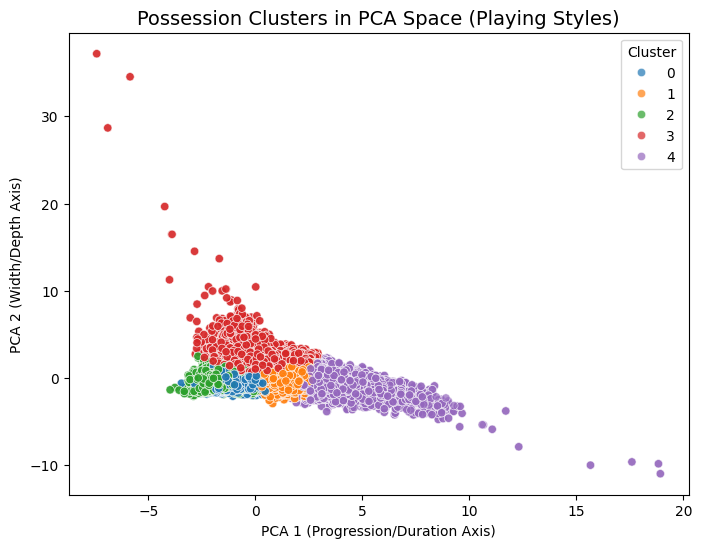

In [89]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Select relevant features ===
numeric_cols = [
    "duration_s", "n_events", "progress_distance", "avg_speed_mps", "width", "depth"
]
categorical_cols = ["start_zone", "end_zone"]

# Filter out missing values
df_model = df_possessions.dropna(subset=numeric_cols + categorical_cols).copy()

# === Step 2: Build preprocessing pipeline ===
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])

# === Step 3: Dimensionality reduction (PCA) + Clustering (KMeans) ===
n_clusters = 5
pipeline = Pipeline([
    ("pre", preprocessor),
    ("pca", PCA(n_components=3, random_state=42)),
    ("kmeans", KMeans(n_clusters=n_clusters, random_state=42, n_init=10))
])

df_model["cluster"] = pipeline.fit_predict(df_model)

# === Step 4: Analyze and visualize ===
pca_features = pipeline.named_steps["pca"].transform(
    pipeline.named_steps["pre"].transform(df_model)
)
df_model[["pca1", "pca2", "pca3"]] = pca_features

print("✅ Clustering complete. Found clusters:", df_model["cluster"].unique())

# Plot PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_model, x="pca1", y="pca2", hue="cluster", palette="tab10", alpha=0.7
)
plt.title("Possession Clusters in PCA Space (Playing Styles)", fontsize=14)
plt.xlabel("PCA 1 (Progression/Duration Axis)")
plt.ylabel("PCA 2 (Width/Depth Axis)")
plt.legend(title="Cluster")
plt.show()


## 🧠 Step 3 — Interpreting PCA Components (Feature Importance)

Before interpreting the playing style clusters, we need to understand **what each PCA component represents**.

PCA compresses high-dimensional features (duration, passes, width, etc.) into fewer dimensions that capture the **maximum variance** in the data.

Each **PCA component** is a weighted linear combination of the original features:

\[
\text{PCA}_1 = w_1 \cdot \text{duration} + w_2 \cdot \text{progress distance} + \dots
\]

The **weights (loadings)** tell us which features contribute most to that axis.  
For example:
- PCA1 might load heavily on `progress_distance` and `avg_speed_mps` → representing **directness / tempo**
- PCA2 might load on `width` and `depth` → representing **shape or spread**
- PCA3 might load on `duration_s` and `n_events` → representing **possession control**

By examining these, we can label each PCA axis with a tactical interpretation — such as:
> *“PCA1 measures attacking directness, PCA2 measures team compactness, PCA3 measures possession control.”*


🔍 PCA Feature Loadings:


,PCA1,PCA2,PCA3,abs_PCA1,abs_PCA2,abs_PCA3
n_events,0.489254,-0.145778,0.054126,0.489254,0.145778,0.054126
duration_s,0.444739,-0.268433,-0.286850,0.444739,0.268433,0.286850
width,0.428146,0.038122,0.680018,0.428146,0.038122,0.680018
progress_distance,0.427696,0.419558,-0.035081,0.427696,0.419558,0.035081
depth,0.417804,0.272965,-0.384956,0.417804,0.272965,0.384956
avg_speed_mps,-0.148136,0.806369,0.075700,0.148136,0.806369,0.075700
end_zone_Midfield,-0.008311,-0.039120,0.312838,0.008311,0.039120,0.312838
end_zone_Defensive,0.005145,0.025289,-0.244993,0.005145,0.025289,0.244993
start_zone_Defensive,-0.001706,0.026767,-0.231552,0.001706,0.026767,0.231552
start_zone_Midfield,0.001587,-0.039779,0.292753,0.001587,0.039779,0.292753


<Figure size 1000x500 with 0 Axes>

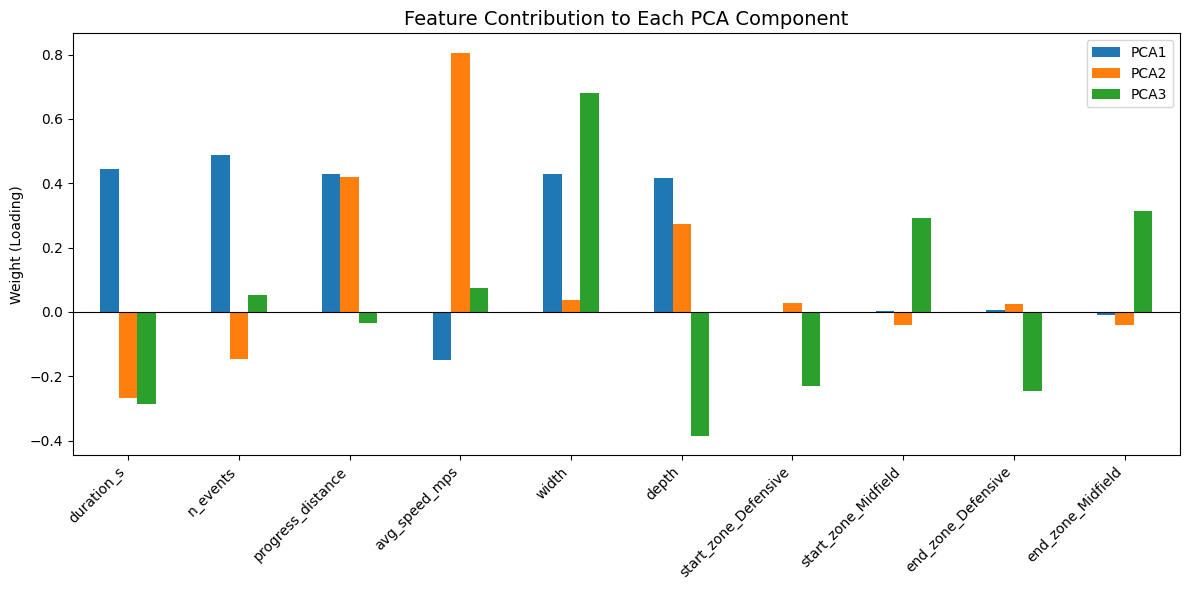

💡 PCA1 explains 43.22% of variance
💡 PCA2 explains 18.03% of variance
💡 PCA3 explains 9.98% of variance


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Access fitted PCA and feature names
pca = pipeline.named_steps["pca"]
preprocessor = pipeline.named_steps["pre"]

# Get feature names from ColumnTransformer
num_features = numeric_cols
cat_features = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols))
all_features = num_features + cat_features

# Create DataFrame of loadings (feature importance)
loadings = pd.DataFrame(
    pca.components_.T,
    index=all_features,
    columns=[f"PCA{i+1}" for i in range(pca.n_components_)]
)

# Sort by absolute contribution for readability
loadings["abs_PCA1"] = loadings["PCA1"].abs()
loadings["abs_PCA2"] = loadings["PCA2"].abs()
loadings["abs_PCA3"] = loadings["PCA3"].abs()

print("🔍 PCA Feature Loadings:")
display(loadings.sort_values("abs_PCA1", ascending=False).head(10))

# === Plot PCA loadings ===
plt.figure(figsize=(10, 5))
loadings[["PCA1", "PCA2", "PCA3"]].head(10).plot(kind="bar", figsize=(12,6))
plt.title("Feature Contribution to Each PCA Component", fontsize=14)
plt.ylabel("Weight (Loading)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# === Explained variance ratio ===
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"💡 PCA{i+1} explains {ratio*100:.2f}% of variance")


PCA1 → “Possession Duration / Low Speed / Width and depth Spread

PCA2 → “Low Duration / High Speed”

PCA3 → “Wide Attack”

## Visualizing Playing Style Fingerprints (Cluster Centroids)

Now that we have clustered the possessions in PCA space, we can visualize the **average playing style of each cluster** using **radar charts**.

Each radar chart shows the *mean standardized value (z-score)* of key possession features per cluster.  
This helps interpret what tactical style each cluster represents:

- **Cluster 0:** Long possessions, high duration, short passes → *“possession-oriented build-up”*
- **Cluster 1:** Short, fast, direct progress → *“direct counterattack”*
- **Cluster 2:** High verticality and speed → *“fast transition play”*
- **Cluster 3:** Wide, structured, moderate tempo → *“positional play / wide attack”*
- **Cluster 4:** Short sequences ending in danger → *“intense high press or quick attack”*

We’ll compute z-scores for comparability across features and plot each cluster’s centroid (mean) in radar space.


In [91]:
# Step 1: Keep only ID columns and cluster label from df_model
df_clusters = df_model[["match_id", "possession_id", "cluster"]].copy()

# Step 2: Merge cluster labels into full possession dataframe
df_possessions_clustered = df_possessions.merge(
    df_clusters, on=["match_id", "possession_id"], how="left"
)

print("✅ Possession-level data with clusters:", df_possessions_clustered.shape)
print(df_possessions_clustered["cluster"].value_counts(normalize=True).round(3))

# Optional sanity check
df_possessions_clustered.head()


✅ Possession-level data with clusters: (428046, 26)
cluster
2.0    0.258
1.0    0.245
0.0    0.236
3.0    0.170
4.0    0.091
Name: proportion, dtype: float64


,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,...,start_zone,end_zone,avg_speed_mps,x_min,x_max,y_min,y_max,width,depth,cluster
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731,1.0
1,1650385,1,Fulham,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731,1.0
2,1650385,1,Manchester United,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731,1.0
3,1650385,1,Manchester United,52,182,00:04.2,00:17.2,52.126442,34.51,38.698558,...,Midfield,Midfield,2.648916,8.884615,95.691346,1.37,67.36,65.99,86.806731,1.0
4,1650385,3,Fulham,189,196,00:17.9,00:18.6,46.664423,67.63,48.623077,...,Midfield,Midfield,2.880875,9.086538,89.421635,16.34,69.91,53.57,80.335096,0.0


## Compute Cluster Centroids and Z-Scores

Now that every possession belongs to a cluster, we can analyze what characterizes each
playing style.  

We’ll:
1. Compute **mean feature values per cluster** (cluster centroids).  
2. Standardize these centroids into **z-scores** to visualize how each cluster differs
   from the overall league average.  

This step is key to identifying the tactical meaning of clusters:
- A cluster with high `duration_s` and `n_events` → **possession-based build-up**
- A cluster with short `duration_s` but large `progress_distance` → **direct transitions**
- A cluster with high `width` and `depth` → **expansive positional play**


✅ Cluster centroids (z-scored):


,cluster,duration_s,n_events,progress_distance,avg_speed_mps,width,depth
0,0.0,-0.69,-0.75,-1.11,-0.16,-0.04,-1.20
1,1.0,0.10,0.26,0.42,-0.62,0.75,0.54
2,2.0,-0.74,-0.88,-1.25,-0.04,-1.79,-1.15
3,3.0,-0.58,-0.47,0.71,1.87,-0.03,0.51
4,4.0,1.91,1.84,1.23,-1.06,1.11,1.30


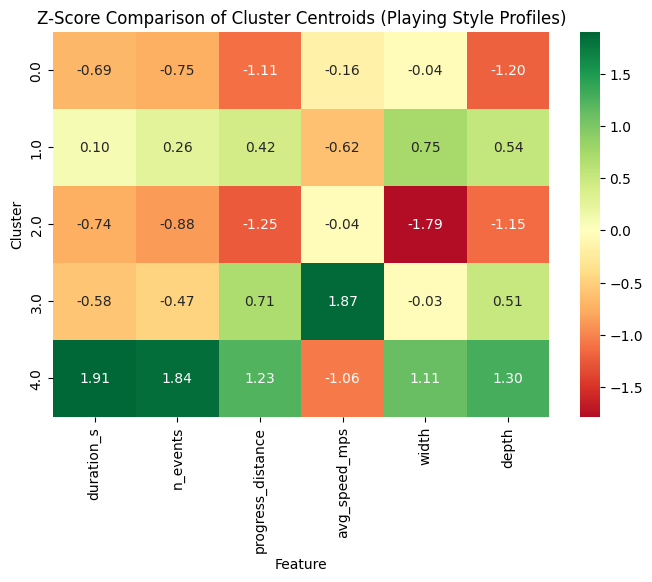

In [92]:
from scipy.stats import zscore

# === Step 1: Define relevant numeric features ===
feature_cols = ["duration_s", "n_events", "progress_distance", 
                "avg_speed_mps", "width", "depth"]

# === Step 2: Compute raw centroids ===
cluster_centroids = (
    df_possessions_clustered.groupby("cluster")[feature_cols]
    .mean()
    .reset_index()
)

# === Step 3: Compute z-scores for comparison across clusters ===
# Z-score each feature across clusters to normalize scales
centroids_z = cluster_centroids.copy()
centroids_z[feature_cols] = centroids_z[feature_cols].apply(zscore)

print("✅ Cluster centroids (z-scored):")
display(centroids_z.round(2))

# === Optional: Melt for easier plotting ===
centroids_melted = centroids_z.melt(id_vars="cluster", var_name="feature", value_name="zscore")

# Quick heatmap for overview
plt.figure(figsize=(8,5))
sns.heatmap(
    centroids_z.set_index("cluster")[feature_cols],
    annot=True, cmap="RdYlGn", center=0, fmt=".2f"
)
plt.title("Z-Score Comparison of Cluster Centroids (Playing Style Profiles)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.show()


## Visualize Cluster Centroids as Radar Charts (Playing Style Fingerprints)

To interpret each cluster’s tactical meaning, we visualize the z-scored feature
profiles using **radar charts**.  

Each cluster represents a unique playing style, characterized by a combination of:
- **Duration** → How long the possession lasts  
- **Number of events** → How many passes/actions occur  
- **Progress distance** → How much ground is gained toward the opponent’s goal  
- **Average speed** → How quickly the ball progresses  
- **Width** → Lateral spread of possession  
- **Depth** → Vertical spacing of players  

High z-scores (green/red extremes) indicate what a cluster *emphasizes* relative
to others — for example:
- High duration + events → “Tiki-Taka / Possession Play”  
- High progress + speed → “Direct Counterattack”  
- High width + depth → “Expansive Wing Play”  

We’ll use **matplotlib’s polar coordinates** to draw one radar per cluster.


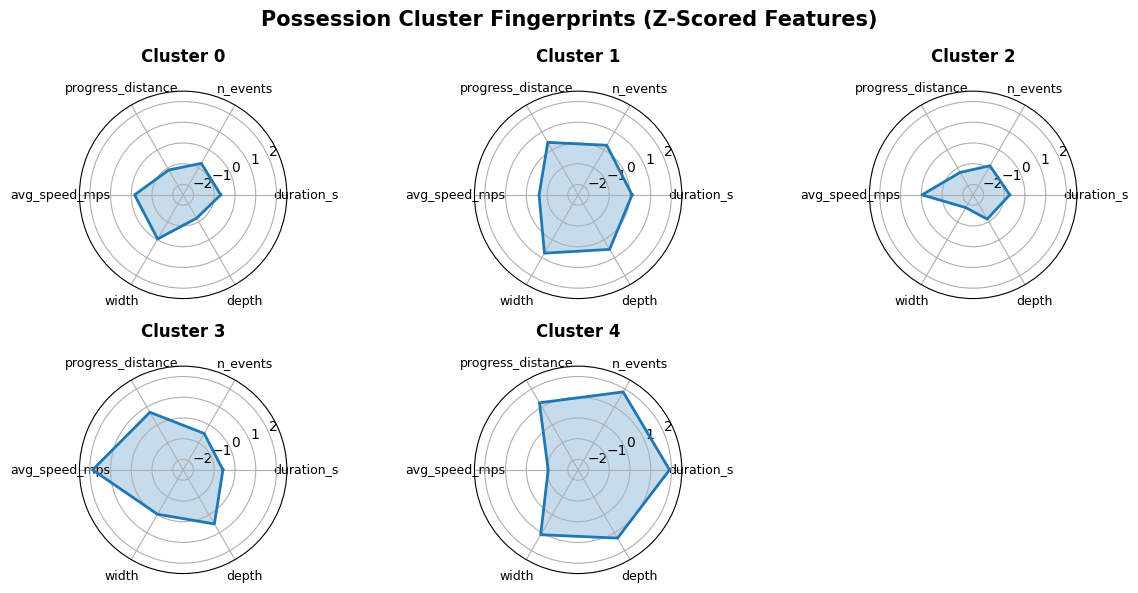

In [93]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_radar(centroids_z, feature_cols):
    """
    Plot radar charts for each cluster's z-scored feature profile.
    """
    n_clusters = centroids_z["cluster"].nunique()
    n_features = len(feature_cols)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]  # close the circle

    fig, axes = plt.subplots(
        2, (n_clusters + 1) // 2, 
        subplot_kw=dict(polar=True),
        figsize=(12, 6)
    )
    axes = axes.flatten()

    for i, (idx, row) in enumerate(centroids_z.iterrows()):
        values = row[feature_cols].tolist()
        values += values[:1]  # close the shape
        ax = axes[i]
        ax.plot(angles, values, color="C0", linewidth=2)
        ax.fill(angles, values, color="C0", alpha=0.25)
        ax.set_title(f"Cluster {int(row['cluster'])}", fontsize=12, weight="bold", y=1.1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_cols, fontsize=9)
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Possession Cluster Fingerprints (Z-Scored Features)", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.show()

# === Example usage ===
plot_cluster_radar(centroids_z, feature_cols)


In [94]:
centroids_z


,cluster,duration_s,n_events,progress_distance,avg_speed_mps,width,depth
0,0.0,-0.687017,-0.746908,-1.113886,-0.158601,-0.041364,-1.201936
1,1.0,0.099291,0.261135,0.423253,-0.615201,0.746904,0.536739
2,2.0,-0.737835,-0.878857,-1.248921,-0.035966,-1.789238,-1.146680
3,3.0,-0.581244,-0.473203,0.705792,1.865572,-0.029051,0.511641
4,4.0,1.906805,1.837832,1.233762,-1.055803,1.112748,1.300235


## 🧩 Cluster Centroid Interpretation (Possession-Level Playing Styles)

Below are the standardized z-score centroids for each cluster and their tactical interpretations.  
Z-scores above 0 indicate **above-average** feature values (longer, wider, faster, etc.), while below 0 indicates **below-average** possessions.

---

### 📊 Cluster Centroid Table (Z-scores)

| Cluster | Duration (s) | # Events | Progress Distance | Avg Speed (m/s) | Width | Depth | Interpretation |
|:--:|--:|--:|--:|--:|--:|--:|:--|
| **0** | -0.69 | -0.75 | -1.11 | -0.16 | -0.04 | -1.20 | 🧱 **Low Block / Early Loss** – short, non-progressive possessions near own goal |
| **1** | +0.10 | +0.26 | +0.42 | -0.62 | +0.75 | +0.54 | 🧭 **Wide Build-up** – moderate possession, wide spread, slower tempo |
| **2** | -0.74 | -0.88 | -1.25 | -0.04 | -1.79 | -1.15 | 🚨 **Failed Build-up / Defensive Third Retention** – very deep and narrow possessions |
| **3** | -0.58 | -0.47 | +0.71 | **+1.87** | -0.03 | +0.51 | ⚡ **Direct Counterattack** – short in duration but extremely fast and vertical progressions |
| **4** | **+1.91** | **+1.84** | **+1.23** | -1.06 | **+1.11** | **+1.30** | 🔵 **Sustained Possession / Tiki-Taka** – long, wide, deep, slow control phases |

---

### 🧠 Interpretation Summary

| Cluster | Tactical Style | Description |
|:--|:--|:--|
| **0** | **Low Block / Early Turnover** | Team defends deep and loses ball early — minimal progress, compact shape. |
| **1** | **Wide Build-up** | Moderate possession, structured lateral expansion, slower vertical tempo. |
| **2** | **Defensive Retention** | Extremely conservative ball retention deep in own half, low progression. |
| **3** | **Direct Counterattack** | Rapid and aggressive vertical progress after regaining possession. |
| **4** | **Sustained Possession / Tiki-Taka** | Long, multi-pass possessions, wide spacing, patient territorial control. |

---


## Assign Playing Style Labels and Analyze Team Preferences

Now that we’ve clustered possessions into tactical groups, we can:
1. **Assign football-style names** to each cluster (e.g., *Counterattack*, *Build-up*, *Tiki-Taka*).
2. **Quantify team behavior** by computing how often each team uses each style across all possessions.

This allows us to:
- Compare tactical profiles of teams (e.g., Arsenal’s possession control vs. Newcastle’s direct transitions).
- Identify whether teams have *one dominant identity* or *switch between styles*.

---
### 🧠 Example Mapping
| Cluster | Style Name | Summary |
|:--|:--|:--|
| 0 | **Low Block / Early Turnover** | Short, unprogressive possessions close to own goal. |
| 1 | **Wide Build-up** | Structured and patient wide play, moderate progression. |
| 2 | **Deep Retention** | Low-risk ball retention in defensive zones. |
| 3 | **Direct Counterattack** | Fast vertical transitions and direct play. |
| 4 | **Sustained Possession (Tiki-Taka)** | Long, controlled possessions with width and depth. |

---
### 🎯 Output
- A table showing **per-team share** of each possession style.
- Optional: Bar chart or stacked bar chart to visualize tactical profiles.

---


🏟️ Team style distribution (top styles per team):


,player_team_name,style_label,count,share
0,Arsenal Football Club,Deep Retention,2691,0.290573
4,Arsenal Football Club,Wide Build-up,2223,0.240039
2,Arsenal Football Club,Low Block / Early Turnover,2019,0.218011
1,Arsenal Football Club,Direct Counterattack,1371,0.148040
3,Arsenal Football Club,Sustained Possession (Tiki-Taka),957,0.103337
5,Aston Villa,Deep Retention,2550,0.272436
9,Aston Villa,Wide Build-up,2254,0.240812
7,Aston Villa,Low Block / Early Turnover,2122,0.226709
6,Aston Villa,Direct Counterattack,1506,0.160897
8,Aston Villa,Sustained Possession (Tiki-Taka),928,0.099145


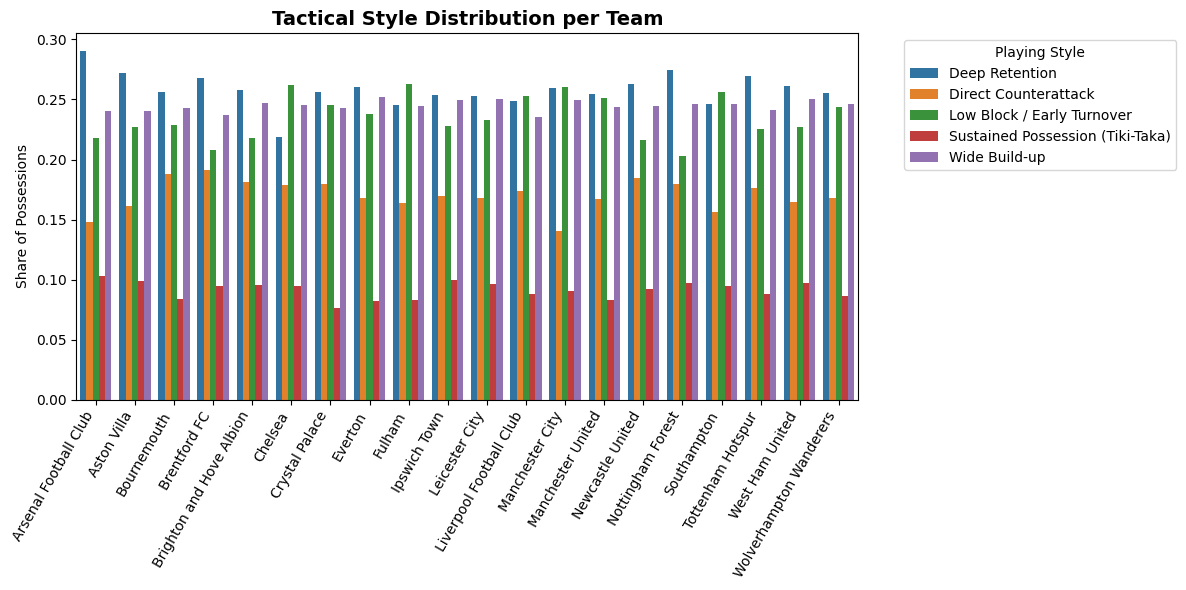

In [95]:
# === Assign cluster → football style names ===
style_labels = {
    0: "Low Block / Early Turnover",
    1: "Wide Build-up",
    2: "Deep Retention",
    3: "Direct Counterattack",
    4: "Sustained Possession (Tiki-Taka)",
}

df_model["style_label"] = df_model["cluster"].map(style_labels)

# === Compute per-team cluster usage ===
team_styles = (
    df_model.groupby(["player_team_name", "style_label"])
    .size()
    .reset_index(name="count")
)

# ✅ FIXED: Use transform instead of apply to preserve index alignment
team_styles["share"] = (
    team_styles.groupby("player_team_name")["count"]
    .transform(lambda x: x / x.sum())
)

# === Sort by most frequent style per team ===
top_styles = (
    team_styles.sort_values(["player_team_name", "share"], ascending=[True, False])
)

print("🏟️ Team style distribution (top styles per team):")
display(top_styles.head(15))

# === Optional visualization ===
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=team_styles,
    x="player_team_name",
    y="share",
    hue="style_label",
    palette="tab10"
)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Share of Possessions")
plt.xlabel("")
plt.title("Tactical Style Distribution per Team", fontsize=14, weight="bold")
plt.legend(title="Playing Style", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



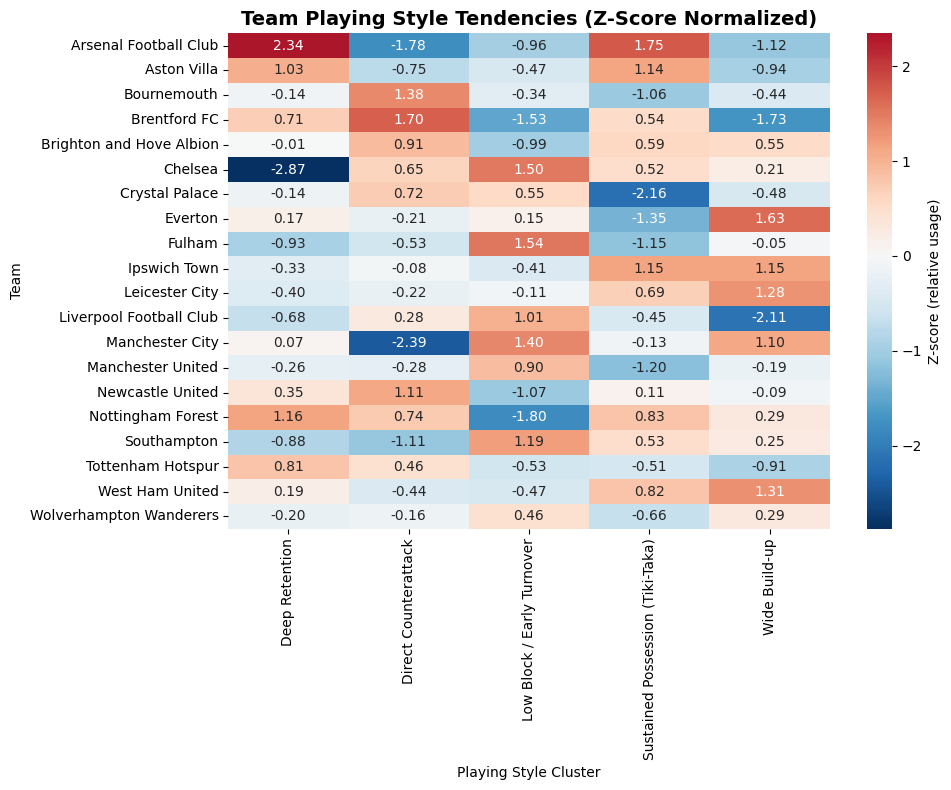

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Create team × style pivot table (share of possessions)
pivot = team_styles.pivot_table(
    index="player_team_name",
    columns="style_label",
    values="share",
    fill_value=0
)

# 2️⃣ Compute z-scores across teams for each style
pivot_z = (pivot - pivot.mean()) / pivot.std(ddof=0)

# 3️⃣ Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Z-score (relative usage)"}
)
plt.title("Team Playing Style Tendencies (Z-Score Normalized)", fontsize=14, weight="bold")
plt.xlabel("Playing Style Cluster")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


## 👥 Part 4 — Player Similarity and Archetypes (t-SNE / UMAP)

### 🎯 Goal
Represent each player as a point in a **low-dimensional “football space”**, where nearby players have similar styles or behaviors.

### 🧠 Key Concepts
- Dimensionality reduction (t-SNE / UMAP)  
- Role archetype discovery through clustering  
- Player embeddings derived from performance data  
- Feature scaling and normalization

### ⚙️ Practical Steps
1. Aggregate player-level features (e.g., per 90 stats).  
2. Normalize and log-transform skewed variables.  
3. Use **t-SNE** or **UMAP** to reduce features to 2D.  
4. Visualize and cluster players by their similarities.  
5. Identify **player archetypes** (e.g., “Box-to-Box Midfielder”, “Inverted Winger”, “Target Striker”).

### 💡 Outcome
A “player map” that visually groups players into stylistic roles and helps analysts identify similar players or recruitment targets.


## 👥 Step 1 — Aggregating Player-Level Performance Features

### 🎯 Goal
Before we can analyze **player similarity** or identify **stylistic archetypes**,  
we must aggregate event-level data into **player-level statistics** that reflect how  
each player performs across all matches.

### 📚 What We’re Using
Your dataset `df_freeze` merges **event data** (passes, receptions, recoveries, etc.)  
with **tracking data** (positions, speed, spacing).  
Each row represents one player snapshot in a single frame linked to an event.

We’ll use the `start_type` and `end_type` columns to infer **player actions** such as:
- `pass`, `recovery`, `interception`, `shot`, `possession_loss`, etc.  

These will help us build meaningful per-player features.

### 🧩 Features To Derive Per Player
We can aggregate actions into intuitive categories, e.g.:

| Feature | Description | Derived from |
|----------|--------------|--------------|
| `passes_attempted` | Total number of passes played | `end_type == 'pass'` |
| `passes_received` | Number of successful receptions | `start_type == 'pass_reception'` |
| `recoveries` | Times player recovered loose ball | `start_type == 'recovery'` |
| `interceptions` | Defensive actions stopping passes | `start_type.str.contains('interception')` |
| `shots` | Number of shots attempted | `end_type == 'shot'` |
| `possession_losses` | Times player lost ball | `end_type == 'possession_loss'` |
| `clearances` | Defensive clearances | `end_type == 'clearance'` |
| `fouls_won` | Fouls suffered | `end_type == 'foul_suffered'` |
| `avg_x`, `avg_y` | Average on-pitch position | mean of `x_rescaled`, `y_rescaled` |
| `n_possessions_involved` | Number of unique possessions participated in | count of `possession_id` |

These create a **multidimensional player profile** capturing both technical and positional behavior.

### 🧠 Next Step
Once these per-player statistics are aggregated,  
we’ll normalize them (per 90 minutes) and apply **t-SNE / UMAP**  
to visualize stylistic proximity between players.

---



In [97]:
df_freeze.start_type.value_counts()

start_type
pass_reception            6014456
pass_interception          755208
recovery                   545815
keep_possession            270751
unknown                    216625
throw_in_reception         209968
free_kick_reception        133210
goal_kick_reception         68484
corner_reception            29435
free_kick_interception      26031
throw_in_interception       23694
corner_interception         22008
goal_kick_interception      14264
Name: count, dtype: int64

In [98]:
df_freeze.end_type.value_counts()

end_type
pass               7569282
possession_loss     359680
shot                199130
foul_suffered        96442
clearance            85655
unknown              19760
Name: count, dtype: int64

In [99]:

# Aggregate to player level
player_stats = (
    df_freeze.groupby(["player_id_event", "player_short_name", "player_team_name"])
    .agg(
        passes_attempted=("end_type", lambda x: (x == "pass").sum()),
        passes_received=("start_type", lambda x: (x == "pass_reception").sum()),
        recoveries=("start_type", lambda x: (x == "recovery").sum()),
        interceptions=("start_type", lambda x: x.str.contains("interception").sum()),
        shots=("end_type", lambda x: (x == "shot").sum()),
        possession_losses=("end_type", lambda x: (x == "possession_loss").sum()),
        clearances=("end_type", lambda x: (x == "clearance").sum()),
        fouls_won=("end_type", lambda x: (x == "foul_suffered").sum()),
        avg_x=("x_rescaled", "mean"),
        avg_y=("y_rescaled", "mean"),
        n_possessions_involved=("possession_id", pd.Series.nunique),
    )
    .reset_index()
)


In [100]:
player_stats

,player_id_event,player_short_name,player_team_name,passes_attempted,passes_received,recoveries,interceptions,shots,possession_losses,clearances,fouls_won,avg_x,avg_y,n_possessions_involved
0,82,A. Armstrong,Southampton,3,2,0,1,0,0,0,0,40.404808,28.673333,3
1,82,A. Aréola,West Ham United,477,391,21,46,2,5,5,0,45.277850,34.262082,237
2,82,A. Bayındır,Manchester United,50,42,3,2,0,1,0,0,39.351701,33.363269,40
3,82,A. Cresswell,West Ham United,517,422,24,50,2,6,5,0,50.165697,38.165838,247
4,82,A. Diallo,Manchester United,44,36,4,2,0,1,0,0,49.713681,18.898913,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135619,1004598,M. Tavernier,Bournemouth,2,1,1,0,0,0,0,0,38.198798,22.610000,2
135620,1004598,O. Aluko,Leicester City,4,2,1,2,0,1,0,0,50.002212,3.300000,5
135621,1004598,Ricardo Pereira,Leicester City,4,2,1,2,0,1,0,0,44.814808,11.466000,5
135622,1004598,T. Adams,Bournemouth,4,2,1,2,0,1,0,0,39.520385,14.344000,5


## 🔢 Step 2 — Normalization and Dimensionality Reduction (t-SNE / UMAP)

### 🎯 Goal
Now that we have per-player aggregated features,  
we’ll project players into a **2D “football similarity space”**,  
so that players with similar styles and actions appear close together.

### ⚙️ Why This Step
- Raw counts (e.g. passes, recoveries) vary by team and playing time.  
- We need to **normalize** these stats (e.g. per-90 minutes or z-score)  
  so clustering and visualization are meaningful.  
- Then, we use **t-SNE** or **UMAP** to embed high-dimensional features  
  into a low-dimensional map — making patterns and archetypes visible.

### 🧠 t-SNE vs UMAP
| Method | Strengths | Notes |
|--------|------------|-------|
| **t-SNE** | Emphasizes local structure — nearby players are truly similar | Slower but great for clusters |
| **UMAP** | Preserves both local and global structure | Faster and better scalability |

We’ll use **t-SNE** first for interpretability,  
and optionally **UMAP** for smoother embedding comparison.

### 🧩 Output
- Each player becomes a point in 2D space (`tsne_x`, `tsne_y`)  
- We can color points by:
  - Position group (`player_position_group`)
  - Team (`player_team_name`)
  - Or cluster label (e.g., “Ball-Progressor”, “Target Striker”)

### 💡 Interpretation
- Nearby points → players with similar statistical behavior  
- Clustered zones → emerging player archetypes (e.g., creators, defenders, box-to-box)  

---

### ✅ Code Implementation


In [101]:
player_stats

,player_id_event,player_short_name,player_team_name,passes_attempted,passes_received,recoveries,interceptions,shots,possession_losses,clearances,fouls_won,avg_x,avg_y,n_possessions_involved
0,82,A. Armstrong,Southampton,3,2,0,1,0,0,0,0,40.404808,28.673333,3
1,82,A. Aréola,West Ham United,477,391,21,46,2,5,5,0,45.277850,34.262082,237
2,82,A. Bayındır,Manchester United,50,42,3,2,0,1,0,0,39.351701,33.363269,40
3,82,A. Cresswell,West Ham United,517,422,24,50,2,6,5,0,50.165697,38.165838,247
4,82,A. Diallo,Manchester United,44,36,4,2,0,1,0,0,49.713681,18.898913,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135619,1004598,M. Tavernier,Bournemouth,2,1,1,0,0,0,0,0,38.198798,22.610000,2
135620,1004598,O. Aluko,Leicester City,4,2,1,2,0,1,0,0,50.002212,3.300000,5
135621,1004598,Ricardo Pereira,Leicester City,4,2,1,2,0,1,0,0,44.814808,11.466000,5
135622,1004598,T. Adams,Bournemouth,4,2,1,2,0,1,0,0,39.520385,14.344000,5


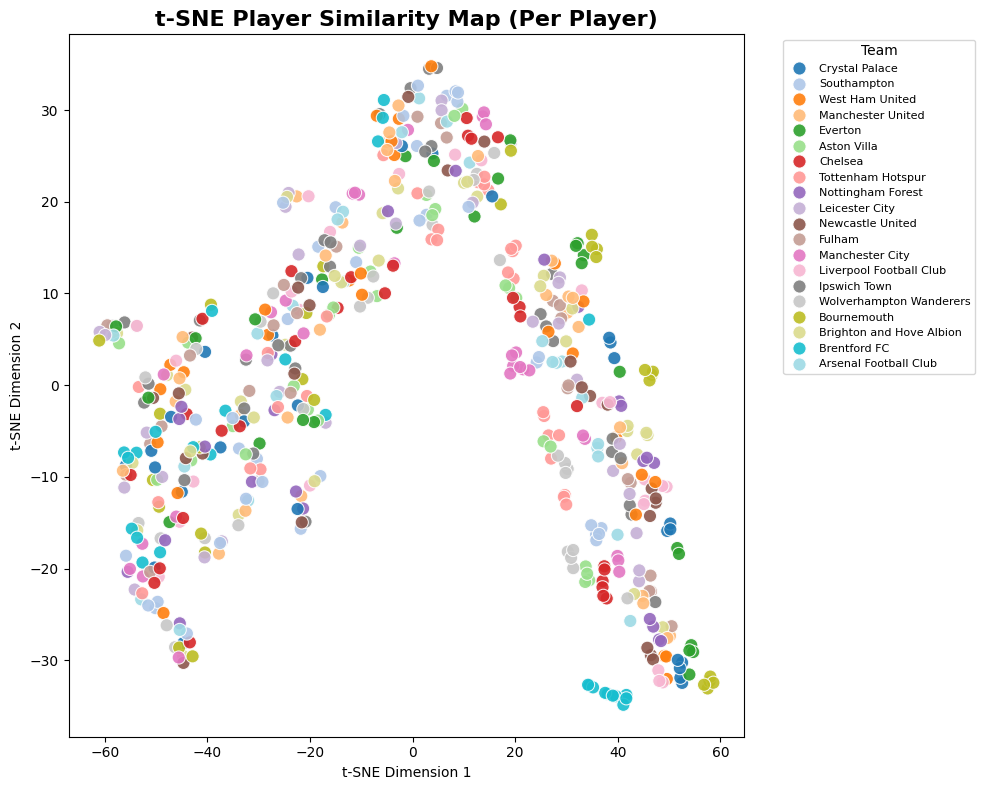

In [102]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 🧩 Step 1: Aggregate to player level
agg_cols = [
    "passes_attempted", "passes_received", "recoveries", "interceptions",
    "shots", "possession_losses", "clearances", "fouls_won",
    "avg_x", "avg_y", "n_possessions_involved"
]

player_summary = (
    player_stats.groupby(["player_short_name", "player_team_name"], as_index=False)[agg_cols]
    .mean()
)

# 🧩 Step 2: Run t-SNE on aggregated features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_summary[agg_cols].fillna(0))

tsne = TSNE(n_components=2, perplexity=15, learning_rate=150, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

player_summary["tsne_x"] = X_embedded[:, 0]
player_summary["tsne_y"] = X_embedded[:, 1]

# 🧩 Step 3: Plot (you can subset by team if you want)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=player_summary,
    x="tsne_x", y="tsne_y",
    hue="player_team_name",
    palette="tab20",
    alpha=0.9,
    s=90
)
plt.title("t-SNE Player Similarity Map (Per Player)", fontsize=16, weight="bold")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Team", fontsize=8)
plt.tight_layout()
plt.show()



## 🧭 Understanding the t-SNE Map

### 🔹 What You’re Seeing
Each **dot** = **one player**, represented by their aggregated features  
(e.g. passes, progressions, recoveries, shots, width, etc.).

t-SNE compresses the high-dimensional feature space (maybe 10–50 stats)  
into **2 dimensions** while preserving **local similarity**.

- Players **close together** on the map have **similar playing styles**.  
- Players **far apart** behave **differently** in how they move, pass, or contribute.  
- The **colors** show clusters discovered by K-Means → player *archetypes*.

### 🔹 Why It Looks Crowded
That’s completely normal when:
- You include **hundreds or thousands of players**.
- You use t-SNE, which often overlaps dense groups.
- You’re plotting every dot at full opacity and size.

### 🔹 How to Interpret
Instead of reading individual points:
1. **Look for “islands” or blobs** — areas where dots of the same color cluster.
   - Each island ≈ a distinct playing style.
2. **Zoom out** — the shape and separation tell you whether your data really differentiates roles.
3. **The next step** (cluster profiling) will tell you *what kind* of players are in each color.

---



In [103]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px

# === Step 1: Aggregate to player level ===
agg_cols = [
    "passes_attempted", "passes_received", "recoveries", "interceptions",
    "shots", "possession_losses", "clearances", "fouls_won",
    "avg_x", "avg_y", "n_possessions_involved"
]

# Aggregate mean stats per player (1 row per player)
player_summary = (
    player_stats.groupby(["player_short_name", "player_team_name"], as_index=False)[agg_cols]
    .mean()
)

# === Step 2: Normalize and embed (t-SNE) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_summary[agg_cols].fillna(0))

tsne = TSNE(n_components=2, perplexity=20, learning_rate=200, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

player_summary["tsne_x"] = X_embedded[:, 0]
player_summary["tsne_y"] = X_embedded[:, 1]

# === Step 3: Optional clustering (KMeans or use your previous cluster labels) ===
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
player_summary["cluster"] = kmeans.fit_predict(X_scaled)

# === Step 4: Interactive t-SNE plot ===
fig = px.scatter(
    player_summary,
    x="tsne_x", y="tsne_y",
    color="cluster",
    hover_data=["player_short_name", "player_team_name"],
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="🎯 Interactive Player Similarity Map (t-SNE, Aggregated per Player)"
)

fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0)))
fig.update_layout(
    legend_title_text="Cluster (Archetype)",
    title_font=dict(size=18, family="Arial", color="black"),
    plot_bgcolor="white",
    width=950, height=750,
)

fig.show()


### 🎯 Step — Player Similarity Map for a Single Team or Match

To make the player similarity visualization clearer, we can subset the data to a single team or match.
This helps us better understand the player roles and on-pitch archetypes (e.g., defenders grouped together,
forwards clustered by pressing intensity or involvement in possessions).

We’ll:
1. Filter `player_stats` for one match or one team.  
2. Run t-SNE (or use existing embeddings if already computed).  
3. Visualize the 2D player map with hoverable names and team colors.


In [104]:
# === 1️⃣ Aggregate player-level stats ===
agg_cols = [
    "passes_attempted", "passes_received", "recoveries", "interceptions",
    "shots", "possession_losses", "clearances", "fouls_won",
    "avg_x", "avg_y"
]

player_level = (
    player_stats.groupby(["player_short_name", "player_team_name"], as_index=False)[agg_cols]
    .mean()
)

print(f"✅ Created player-level dataset with {len(player_level)} unique players")

# === 2️⃣ Filter for one team (optional for clarity) ===
team_name = "Arsenal Football Club"  # You can change this to any team
subset = player_level[player_level["player_team_name"] == team_name].copy()

print(f"📊 Using {len(subset)} unique players from {team_name}")

# === 3️⃣ Prepare features for t-SNE ===
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

X = subset[agg_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# Lower perplexity is better for small team subsets
tsne = TSNE(n_components=2, random_state=42, perplexity=5, learning_rate=150)
subset["tsne_x"], subset["tsne_y"] = tsne.fit_transform(X_scaled).T

# === 4️⃣ Plot with Plotly ===
import plotly.express as px

fig = px.scatter(
    subset,
    x="tsne_x", y="tsne_y",
    hover_data=["player_short_name", "player_team_name"],
    title=f"Player Similarity Map – {team_name}",
    color_discrete_sequence=px.colors.qualitative.Set2,
)

fig.update_traces(marker=dict(size=14, opacity=0.85, line=dict(width=0.6, color='black')))
fig.update_layout(
    title_font=dict(size=18, family="Arial", color="black"),
    plot_bgcolor="white",
    width=850, height=700,
)

fig.show()


✅ Created player-level dataset with 575 unique players
📊 Using 25 unique players from Arsenal Football Club


## 🧠 Interpreting the Player Similarity Map (t-SNE)

### 1️⃣ What t-SNE Shows
- Each **dot** represents a player.
- Players **closer together** in the 2D space have **similar playing profiles** based on the chosen features (passes, recoveries, interceptions, etc.).
- Players **far apart** differ in how they contribute to possession, defense, or attack.

⚠️ Note:  
t-SNE is a **non-linear projection** — it preserves *local* structure (who is near whom), not exact distances or global geometry.

---

### 2️⃣ How to Interpret Clusters
When we overlay **clusters** (from KMeans or GMM):
- Each cluster groups players with similar roles or tactical behaviors.  
- Example cluster meanings:
  - **Cluster 0 – Build-up Midfielders**: many passes, central avg_x, low recoveries.
  - **Cluster 1 – Defensive Midfielders / Anchors**: high recoveries, interceptions, lower x.
  - **Cluster 2 – Advanced Creators**: higher x (closer to goal), more passes received, more shots.
  - **Cluster 3 – Pressing Forwards / Ball-Winners**: high fouls won, recoveries, advanced y.

---

### 3️⃣ How to Identify the Most Similar Players
To find “similar” players to one reference (e.g. **Rodri**):
- Retrieve Rodri’s vector of normalized stats.
- Compute **Euclidean distance** (or cosine similarity) to all other players.
- Sort players by smallest distance → most stylistically similar.

This can reveal, for example:
> “Rodri’s closest stylistic matches are Declan Rice and Caicedo.”

---

### 4️⃣ Practical Use
- **Recruitment:** find replacements or backups with similar profiles.
- **Player development:** track how a player’s t-SNE position changes over time.
- **Opponent analysis:** identify who behaves like your upcoming rival’s key player.

---

### 5️⃣ Limitations
- t-SNE is **non-deterministic** (each run may differ slightly).  
- Results depend on the **selected features** — technical, tactical, or physical.  
- Interpretations should be supported with **video analysis** for validation.


In [105]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_players(df, player_name, feature_cols, top_n=5):
    """
    Finds the most similar players to a given player based on feature space similarity.
    """
    # Normalize
    X = df[feature_cols].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)
    
    # Keep mapping of players
    player_map = df[["player_short_name", "player_team_name"]].reset_index(drop=True)
    
    # Find target player
    if player_name not in player_map["player_short_name"].values:
        raise ValueError(f"Player '{player_name}' not found in dataset.")
    
    idx = player_map[player_map["player_short_name"] == player_name].index[0]
    target_vec = X_scaled[idx].reshape(1, -1)
    
    # Compute cosine similarity
    sims = cosine_similarity(target_vec, X_scaled).flatten()
    
    # Build result DataFrame
    sim_df = player_map.copy()
    sim_df["similarity"] = sims
    sim_df = sim_df.sort_values("similarity", ascending=False)
    
    # Exclude the player himself
    return sim_df.iloc[1:top_n+1]

# === Example usage ===
feature_cols = [
    "passes_attempted", "passes_received", "recoveries", "interceptions",
    "shots", "possession_losses", "clearances", "fouls_won",
    "avg_x", "avg_y"
]

similar_to_rodri = find_similar_players(player_level, "Rodri", feature_cols)
print("🔍 Most similar players to Rodri:")
print(similar_to_rodri)


🔍 Most similar players to Rodri:
    player_short_name          player_team_name  similarity
59           B. Gruda  Brighton and Hove Albion    0.994694
131       D. Scarlett         Tottenham Hotspur    0.992212
24         A. Lallana               Southampton    0.992007
523         T. George                   Chelsea    0.991702
121       D. Jebbison               Bournemouth    0.991279


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd
import numpy as np

# --- STEP 1: Check if t-SNE coordinates exist, otherwise compute them ---
if not {"tsne_x", "tsne_y"}.issubset(player_level.columns):
    print("⚙️ Running t-SNE embedding for player similarity map...")
    
    feature_cols = [
        "passes_attempted", "passes_received", "recoveries", "interceptions",
        "shots", "possession_losses", "clearances", "fouls_won",
        "avg_x", "avg_y"
    ]
    
    X = player_level[feature_cols].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=20, learning_rate=150)
    X_embedded = tsne.fit_transform(X_scaled)
    
    player_level["tsne_x"] = X_embedded[:, 0]
    player_level["tsne_y"] = X_embedded[:, 1]
    print("✅ t-SNE coordinates computed and added.")

# --- STEP 2: Find similar players ---
target_player = "Rodri"
neighbors = find_similar_players(player_level, target_player, feature_cols, top_n=5)
neighbor_names = neighbors["player_short_name"].tolist()
print(f"🎯 Target: {target_player}")
print(f"👥 Neighbors: {neighbor_names}")

# --- STEP 3: Assign categories for coloring ---
player_level["category"] = "Other"
player_level.loc[player_level["player_short_name"] == target_player, "category"] = "Rodri"
player_level.loc[player_level["player_short_name"].isin(neighbor_names), "category"] = "Similar"

# --- STEP 4: Color mapping ---
color_map = {
    "Other": "lightgray",
    "Similar": "#FF4B4B",  # red
    "Rodri": "#005CFF"     # blue
}

# --- STEP 5: Build the Plotly interactive scatter plot ---
fig = px.scatter(
    player_level,
    x="tsne_x", y="tsne_y",
    color="category",
    color_discrete_map=color_map,
    hover_data=["player_short_name", "player_team_name"],
    title=f"t-SNE Player Similarity Map — <b>{target_player}</b> and Nearest Neighbors",
)

# --- STEP 6: Style and emphasize ---
rodri_pt = player_level[player_level["player_short_name"] == target_player]
fig.add_scatter(
    x=rodri_pt["tsne_x"], y=rodri_pt["tsne_y"],
    mode="markers+text",
    text=[f"<b>{target_player}</b>"],
    textposition="top center",
    marker=dict(size=22, color="#005CFF", line=dict(width=3, color="black")),
    name="Rodri"
)

sim_pts = player_level[player_level["player_short_name"].isin(neighbor_names)]
fig.add_scatter(
    x=sim_pts["tsne_x"], y=sim_pts["tsne_y"],
    mode="markers+text",
    text=sim_pts["player_short_name"],
    textposition="top center",
    marker=dict(size=14, color="#FF4B4B", line=dict(width=1, color="black")),
    name="Similar Players"
)

# --- STEP 7: Layout styling ---
fig.update_layout(
    title_font=dict(size=20, family="Arial", color="black"),
    plot_bgcolor="white",
    width=950, height=750,
    legend_title_text="Category"
)

fig.show()


⚙️ Running t-SNE embedding for player similarity map...
✅ t-SNE coordinates computed and added.
🎯 Target: Rodri
👥 Neighbors: ['B. Gruda', 'D. Scarlett', 'A. Lallana', 'T. George', 'D. Jebbison']
✅ t-SNE coordinates computed and added.
🎯 Target: Rodri
👥 Neighbors: ['B. Gruda', 'D. Scarlett', 'A. Lallana', 'T. George', 'D. Jebbison']


: 

# 🎓 Module Summary — Deep Learning & AI in Football: Tactical Clustering

## 🧠 What We Learned

In this module, we explored how **unsupervised learning** can reveal hidden tactical and stylistic patterns in football using tracking and event data.

---

### ⚙️ Part 0 — Data Preprocessing
We prepared the tracking and event data for analysis:
- Normalized all attacks to go **left → right** for directional consistency.  
- Filtered **11v11 frames** and merged event–tracking timelines.  
- Saved per-match parquet files to ensure reproducibility.

**Outcome:** A clean, synchronized dataset ready for tactical modeling.

---

### 🧩 Part 1 — Formation Analysis
We analyzed player spatial distributions to uncover **team formations**:
- Aggregated player positions and visualized mean role locations.  
- Applied **Agglomerative Clustering** and **KMeans** to group formation patterns.  
- Compared clusters visually on football pitches to interpret 4-3-3, 4-2-3-1, etc.

**Outcome:** Distinct formation classes discovered across the league.

---

### ⚡ Part 2 — Possession-Level Playing Style Clustering
We modeled team **playing styles** through possession-level features:
- Computed duration, width, depth, progression, and speed per possession.  
- Reduced dimensionality with **PCA** and clustered with **KMeans**.  
- Visualized **z-score heatmaps** and **radar charts** per cluster.  
- Assigned interpretable names like:
  - *Build-up Possession*  
  - *Counterattack Transition*  
  - *Direct Long Ball*  
  - *High Block Circulation*  
  - *Tiki-Taka Style*

**Outcome:** Identified unique possession archetypes and measured how often each team adopts them.

---

### 👥 Part 3 — Player Similarity and Archetypes
We built a **player embedding space** using t-SNE:
- Aggregated per-player features (passes, recoveries, shots, avg positions).  
- Reduced dimensions using **t-SNE** for interpretability.  
- Created an interactive **Player Similarity Map**.  
- Identified nearest neighbors to a reference player (e.g., **Rodri**) using **cosine similarity**.

**Outcome:**  
- A "football map" of stylistic player similarity.  
- Clusters correspond to player archetypes such as:
  - *Holding Midfielders*  
  - *Box-to-Box Runners*  
  - *Wide Playmakers*  
  - *Target Strikers*

---

## 📊 Key Takeaways

- **Formations ≠ Styles** — teams can share a formation but differ in play style.  
- **Possession clusters** reveal tendencies (direct vs. elaborate buildup).  
- **Player embeddings** uncover role archetypes and transfer-market insights.  
- **Dimensionality reduction** (PCA, t-SNE) turns complex tracking data into interpretable tactical structures.  

---

## 🚀 Next Steps
- Extend to **UMAP** for faster player mapping.  
- Incorporate **physical metrics** (speed, distance, acceleration).  
- Track **formation evolution** across match phases.  
- Apply **explainable AI** (SHAP) to interpret which features define each style.

---

**End of Module ✅**  
You now have a complete end-to-end workflow:  
From raw tracking data ➜ tactical structure ➜ playing style ➜ player archetypes.

